In [1]:
# Load Gemini API key from Colab Secrets
# Add GEMINI_KEY to the Secrets panel (left sidebar) before running.

from google.colab import userdata

MY_GEMINI_KEY = userdata.get('GEMINI_KEY')

if not MY_GEMINI_KEY:
    raise ValueError("GEMINI_KEY not found in Colab Secrets")

print("Gemini API key loaded")

✅ Gemini API key loaded (AIza…rMrc)


In [2]:
# Build ARIA-DB from HookTheory source CSVs.
# Loads valence/energy/mode features and converts numeric chord progressions
# to Roman numeral notation.

import pandas as pd
import io
from google.colab import files

# Numeric → Roman-numeral lookup
CHORD_DICT = {
    '1': 'I',  '2': 'ii', '3': 'iii', '4': 'IV',
    '5': 'V',  '6': 'vi', '7': 'vii°'
}

def translate_cp(cp_string):
    """Convert '1,5,6,4' → 'I - V - vi - IV'."""
    try:
        return ' - '.join(CHORD_DICT.get(c.strip(), c.strip())
                          for c in str(cp_string).split(','))
    except Exception:
        return str(cp_string)

# Upload source CSVs
print("📤 Upload your 3 source CSVs for ARIA-DB:")
uploaded = files.upload()

# Load and clean each CSV
all_dfs  = []
required = {'cp', 'valence', 'energy', 'artist', 'song'}

for filename, content in uploaded.items():
    df = pd.read_csv(io.BytesIO(content))

    if required.issubset(df.columns):
        cols = list(required)
        if 'mode' in df.columns:
            cols.append('mode')
        clean = df[cols].dropna()
        all_dfs.append(clean)
        print(f"  ✅ {filename}: {len(clean)} rows (full features)")
    elif 'cp' in df.columns:
        clean = df[['cp']].dropna()
        all_dfs.append(clean)
        print(f"  ⚠️  {filename}: {len(clean)} rows (cp only)")
    else:
        print(f"  ❌ {filename}: skipped (no 'cp' column)")

# Merge into ARIA-DB
aria_db = pd.concat(all_dfs, ignore_index=True)

if {'artist', 'song'}.issubset(aria_db.columns):
    aria_db = aria_db.drop_duplicates(subset=['artist', 'song'])

aria_db['roman'] = aria_db['cp'].apply(translate_cp)

music_db = aria_db

# Status report
print(f"\n🎼 ARIA-DB ready: {len(aria_db):,} unique songs")
print(f"   Columns: {aria_db.columns.tolist()}")
print(aria_db.head())

📤 Upload your 3 source CSVs for ARIA-DB:


Saving three_four_five_pruned.csv to three_four_five_pruned.csv
Saving three_four_five_has_audio_pruned.csv to three_four_five_has_audio_pruned.csv
Saving three_four_five.csv to three_four_five.csv
Saving three_chord_songs.csv to three_chord_songs.csv
Saving four_chord_songs.csv to four_chord_songs.csv
Saving five_chord_songs.csv to five_chord_songs.csv
  ✅ three_four_five_pruned.csv: 12511 rows (full features)
  ✅ three_four_five_has_audio_pruned.csv: 12511 rows (full features)
  ✅ three_four_five.csv: 36300 rows (full features)
  ✅ three_chord_songs.csv: 14485 rows (full features)
  ✅ four_chord_songs.csv: 11931 rows (full features)
  ✅ five_chord_songs.csv: 9884 rows (full features)

🎼 ARIA-DB ready: 3,263 unique songs
   Columns: ['valence', 'energy', 'song', 'cp', 'artist', 'mode', 'roman']
   valence  energy                      song     cp        artist  mode  \
0    0.486   0.856                    cryin'  1,5,6     aerosmith   1.0   
1    0.964   0.657                     flak

In [3]:
# ARIA chord retrieval algorithm.
# Filters ARIA-DB by valence/energy/mode to find chord progressions
# that match the detected emotion's musical character.

# Emotion → audio-feature filter rules
EMOTION_FILTERS = {
    "sadness":        {"valence_max": 0.30, "energy_max": 0.45},
    "grief":          {"valence_max": 0.25, "energy_max": 0.35},
    "joy":            {"valence_min": 0.70, "energy_min": 0.60},
    "excitement":     {"valence_min": 0.65, "energy_min": 0.75},
    "anger":          {"valence_max": 0.40, "energy_min": 0.72, "mode": 0},
    "fear":           {"valence_max": 0.38, "energy_min": 0.50,
                       "energy_max": 0.72,  "mode": 0},
    "calmness":       {"valence_min": 0.45, "energy_max": 0.40},
    "love":           {"valence_min": 0.55, "energy_min": 0.30, "energy_max": 0.60},
    "disappointment": {"valence_max": 0.40, "energy_max": 0.50},
}

# Map 27 GoEmotions classes to 9 musical buckets
GOEMOTIONS_TO_MUSICAL = {
    "joy": "joy",               "amusement": "joy",          "optimism": "joy",
    "excitement": "excitement", "pride": "excitement",
    "sadness": "sadness",       "disappointment": "disappointment",
    "grief": "grief",           "remorse": "sadness",        "embarrassment": "sadness",
    "anger": "anger",           "annoyance": "anger",        "disgust": "anger",
    "fear": "fear",             "nervousness": "fear",
    "relief": "calmness",       "approval": "calmness",      "gratitude": "calmness",
    "calmness": "calmness",
    "love": "love",             "caring": "love",            "admiration": "love",
    "neutral": "calmness",      "surprise": "joy",           "curiosity": "joy",
    "realization": "calmness",  "confusion": "fear",
}


def aria_retrieve(detected_emotion, db=None, top_n=3):
    """Retrieve top-N chord progressions matching an emotion."""
    if db is None:
        db = aria_db

    musical_emotion = GOEMOTIONS_TO_MUSICAL.get(detected_emotion, "joy")
    rules = EMOTION_FILTERS.get(musical_emotion, {})
    filtered = db.copy()

    if 'valence' in filtered.columns and 'energy' in filtered.columns:
        if "valence_min" in rules: filtered = filtered[filtered['valence'] >= rules['valence_min']]
        if "valence_max" in rules: filtered = filtered[filtered['valence'] <= rules['valence_max']]
        if "energy_min"  in rules: filtered = filtered[filtered['energy']  >= rules['energy_min']]
        if "energy_max"  in rules: filtered = filtered[filtered['energy']  <= rules['energy_max']]
    if "mode" in rules and 'mode' in filtered.columns:
        filtered = filtered[filtered['mode'] == rules['mode']]

    # Fall back to a relaxed filter if too few matches
    if len(filtered) < 5:
        print(f"  Note: strict filter returned {len(filtered)} songs, applying relaxed filter.")
        filtered = db.copy()
        if 'valence' in db.columns:
            v_mid = (rules.get('valence_min', 0.5) + rules.get('valence_max', 0.5)) / 2
            filtered = filtered[(filtered['valence'] - v_mid).abs() < 0.25]

    top_progressions = filtered['cp'].value_counts().head(top_n)
    results = []
    for cp, count in top_progressions.items():
        examples = (filtered[filtered['cp'] == cp][['artist', 'song', 'valence', 'energy']]
                    .drop_duplicates().head(2))
        results.append({"cp": cp, "roman": translate_cp(cp),
                        "count": int(count), "examples": examples})
    return musical_emotion, results


def generate_aria_chords(detected_emotion, db=None):
    """Return top-1 progression as a list of Roman numerals."""
    _, results = aria_retrieve(detected_emotion, db=db, top_n=1)
    if not results:
        return ['I', 'V', 'vi', 'IV']
    return [c.strip() for c in results[0]['roman'].split('-')]


def aria_demo(detected_emotion, db=None):
    """Pretty-print retrieval results for testing."""
    if db is None:
        db = aria_db
    musical_emotion, results = aria_retrieve(detected_emotion, db)
    print(f"\n--- [{detected_emotion.upper()} → bucket: {musical_emotion.upper()}] ---")
    for r in results:
        print(f"  {r['roman']} ({r['count']} songs)")
        for _, row in r['examples'].iterrows():
            print(f"    ↳ {row['artist'].title()} — '{row['song'].title()}' "
                  f"(Val:{row['valence']:.2f}, Nrg:{row['energy']:.2f})")
    best = results[0]['roman'] if results else "I - V - vi - IV"
    print(f"\n  Best match: {best}")
    return best


query_db_for_emotion     = aria_retrieve
print_emotion_query      = aria_demo
generate_musetune_chords = generate_aria_chords


# Quick test across a few emotions
for emotion in ["sadness", "joy", "anger", "fear", "calmness"]:
    aria_demo(emotion, aria_db)


--- [SADNESS → bucket: SADNESS] ---
  IV - V - I (11 songs)
    ↳ Kenny Chesney — 'The Road And The Radio' (Val:0.19, Nrg:0.43)
    ↳ John Lennon — 'Imagine' (Val:0.17, Nrg:0.26)
  IV - I - V (9 songs)
    ↳ Counting Crows — 'Walkaways' (Val:0.17, Nrg:0.29)
    ↳ Johnny Cash — 'Hurt' (Val:0.17, Nrg:0.40)
  IV - V - vi (9 songs)
    ↳ Elvis Presley — 'Can'T Help Falling In Love' (Val:0.15, Nrg:0.24)
    ↳ Elvis Presley — 'I Can'T Help Falling In Love' (Val:0.10, Nrg:0.21)

  Best match: IV - V - I

--- [JOY → bucket: JOY] ---
  I - V - vi - IV - I (33 songs)
    ↳ Flo Rida — 'Whistle' (Val:0.74, Nrg:0.94)
    ↳ Matchbox 20 — 'Real World' (Val:0.88, Nrg:0.76)
  I - V - IV - I - V (30 songs)
    ↳ Bruno Mars — 'The Lazy Song' (Val:0.95, Nrg:0.80)
    ↳ Creedence Clearwater Revival — 'Bad Moon Rising' (Val:0.94, Nrg:0.77)
  I - IV - V - I - IV (19 songs)
    ↳ One Direction — 'What Makes You Beautiful' (Val:0.87, Nrg:0.77)
    ↳ Train — 'Save Me San Francisco' (Val:0.89, Nrg:0.94)

  Best

In [4]:
# ============================================================
# CELL 4: Clone ChoCo — enrich ARIA-DB with chord corpus data
# ============================================================
# ChoCo is a public chord corpus (Wikifonia, Isophonics, Real
# Book, etc.) distributed in JAMS format. It will form the
# second pillar of ARIA-DB alongside HookTheory.
# ============================================================

import os

REPO_DIR = "choco"
PARTITIONS_PATH = os.path.join(REPO_DIR, "partitions")

# Clone (or skip if already cloned)
if os.path.exists(REPO_DIR):
    print(f"✅ ChoCo already cloned at './{REPO_DIR}/' — skipping")
else:
    !git clone --quiet https://github.com/smashub/choco.git
    print(f"✅ ChoCo cloned into './{REPO_DIR}/'")

# Explore partitions
if os.path.exists(PARTITIONS_PATH):
    print("\n📚 ARIA-DB enrichment sources available:")
    for folder in sorted(os.listdir(PARTITIONS_PATH)):
        folder_path = os.path.join(PARTITIONS_PATH, folder)
        if os.path.isdir(folder_path):
            file_count = sum(len(files) for _, _, files in os.walk(folder_path))
            print(f"  {folder} — {file_count} files")
else:
    print("❌ Partitions folder not found")

✅ ChoCo cloned into './choco/'

📚 ARIA-DB enrichment sources available:
  biab-internet-corpus — 9995 files
  billboard — 2685 files
  chordify — 114 files
  ireal-pro — 80167 files
  isophonics — 538 files
  jaah — 215 files
  jazz-corpus — 170 files
  mozart-piano-sonatas — 179 files
  nottingham — 2034 files
  real-book — 8554 files
  robbie-williams — 267 files
  rock-corpus — 2220 files
  rwc-pop — 318 files
  schubert-winterreise — 1947 files
  uspop2002 — 599 files
  weimar — 1835 files
  when-in-rome — 6424 files
  wikifonia — 18914 files


In [5]:
# ============================================================
# CELL 5: Install JAMS + Harte note lookup
# ============================================================
# Installs the JAMS library used to parse ChoCo's .jams files,
# and defines the chromatic note → semitone lookup that the
# rest of the parser uses to convert Harte chord symbols
# (e.g. "C:maj", "A:min7") into Roman numerals.
# ============================================================

!pip install -q jams

import jams
import os
import pandas as pd

# ── Harte note → semitone lookup (for billboard, ireal-forum) ──
NOTE_TO_SEMI = {
    'C': 0,  'C#': 1, 'Db': 1, 'D': 2,  'D#': 3, 'Eb': 3,
    'E': 4,  'Fb': 4, 'F': 5,  'F#': 6, 'Gb': 6, 'G': 7,
    'G#': 8, 'Ab': 8, 'A': 9,  'A#':10, 'Bb':10, 'B':11, 'Cb':11
}

# ── Rest of your existing parser code stays exactly the same ──

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 8.6 MB/s eta 0:00:00


In [6]:
# ============================================================
# CELL 6: Parse ChoCo JAMS → enrich ARIA-DB
# ============================================================
# Walks each ChoCo partition (billboard, rock-corpus, ireal-pro)
# and converts every chord progression to Roman numerals so it
# can join ARIA-DB. Three notation formats are supported:
#   • Harte         (e.g. "C:maj", "A:min7")    → harte_to_roman()
#   • chord_roman   (e.g. "G:IV")               → roman_label_to_clean()
#   • iReal Pro     (e.g. "F-7", "Eb^7")        → ireal_to_roman()
# ============================================================

import jams
import os
import pandas as pd

# ─── Lookup tables ───────────────────────────────────────────
NOTE_TO_SEMI = {
    'C':0, 'C#':1, 'Db':1, 'D':2, 'D#':3, 'Eb':3,
    'E':4, 'Fb':4, 'F':5, 'F#':6, 'Gb':6, 'G':7,
    'G#':8, 'Ab':8, 'A':9, 'A#':10, 'Bb':10, 'B':11, 'Cb':11
}
INTERVAL_TO_DEGREE = {0:1, 2:2, 4:3, 5:4, 7:5, 9:6, 11:7}
DEGREE_TO_ROMAN    = {1:'I', 2:'II', 3:'III', 4:'IV', 5:'V', 6:'VI', 7:'VII'}


# ─── Harte → Roman (billboard, ireal-forum) ──────────────────
def harte_to_roman(chord_str, key_root):
    try:
        root, quality = (chord_str.split(':', 1) + ['maj'])[:2]
        chord_semi = NOTE_TO_SEMI.get(root)
        key_semi   = NOTE_TO_SEMI.get(key_root, 0)
        if chord_semi is None:
            return None
        interval = (chord_semi - key_semi) % 12
        degree   = INTERVAL_TO_DEGREE.get(interval)
        if degree is None:
            return None
        roman = DEGREE_TO_ROMAN[degree]
        if any(quality.startswith(q) for q in ['min', 'dim', 'hdim']):
            roman = roman.lower()
        if quality == 'maj7':
            roman += 'maj7'
        elif quality.startswith('dim'):
            roman += '°'
        elif '7' in quality:
            roman += '7'
        return roman
    except Exception:
        return None


# ─── chord_roman label cleanup (rock-corpus) ─────────────────
def roman_label_to_clean(chord_str):
    """Extract Roman numeral from 'G:I' or 'G:IV' format."""
    try:
        if ':' in chord_str:
            return chord_str.split(':', 1)[1].strip()
        return chord_str.strip()
    except Exception:
        return None


# ─── iReal Pro → Roman (ireal-playlists) ─────────────────────
def ireal_to_roman(chord_str, key_root):
    """Convert iReal Pro chord (e.g. 'F-7', 'Bb7', 'Eb^7') → Roman numeral."""
    try:
        chord_str = chord_str.strip()
        if not chord_str or chord_str in ('n', 'N', 'x', 'X'):
            return None

        # Extract root (1–2 characters)
        root = chord_str[0]
        rest = chord_str[1:]
        if rest and rest[0] in ('#', 'b'):
            root += rest[0]
            rest = rest[1:]

        chord_semi = NOTE_TO_SEMI.get(root)
        key_semi   = NOTE_TO_SEMI.get(key_root, 0)
        if chord_semi is None:
            return None

        interval = (chord_semi - key_semi) % 12
        degree   = INTERVAL_TO_DEGREE.get(interval)
        if degree is None:
            return None

        roman = DEGREE_TO_ROMAN[degree]
        is_minor = rest.startswith('-') or rest.startswith('m')
        if is_minor:
            roman = roman.lower()

        if '^7' in rest or '^' in rest:
            roman += 'maj7'
        elif rest.startswith('o') or rest.startswith('°'):
            roman = roman.lower() + '°'
        elif '7' in rest:
            roman += '7'

        return roman
    except Exception:
        return None


# ─── Universal JAMS folder parser ────────────────────────────
def parse_jams_folder(jams_folder, source_name, max_files=None):
    """Parse every .jams in a folder → list of progression dicts."""
    if not os.path.exists(jams_folder):
        print(f"  ❌ Folder not found: {jams_folder}")
        return []

    jams_files = [f for f in os.listdir(jams_folder) if f.endswith('.jams')]
    if max_files:
        jams_files = jams_files[:max_files]

    results = []
    errors  = 0

    for filename in jams_files:
        try:
            jam    = jams.load(os.path.join(jams_folder, filename), validate=False)
            title  = str(jam.file_metadata.title  or '').lower().strip()
            artist = str(jam.file_metadata.artist or '').lower().strip()

            # Detect song key
            song_key = 'C'
            for ann in jam.annotations:
                if ann.namespace == 'key_mode' and len(ann.data) > 0:
                    song_key = str(ann.data[0].value).split(':')[0].strip()
                    break

            # Pull chord sequence from any supported namespace
            chord_seq  = []
            chord_type = None
            for ann in jam.annotations:
                if ann.namespace in ('chord', 'chord_roman', 'chord_ireal'):
                    chord_type = ann.namespace
                    for obs in ann.data:
                        val = str(obs.value).strip()
                        if val not in ('N', 'X', 'n', 'x', '', 'nan'):
                            chord_seq.append(val)
                    break

            if len(chord_seq) < 3:
                continue

            # Convert using the right converter
            if chord_type == 'chord_roman':
                roman_list = [roman_label_to_clean(c) for c in chord_seq]
            elif chord_type == 'chord_ireal':
                roman_list = [ireal_to_roman(c, song_key) for c in chord_seq]
            else:
                roman_list = [harte_to_roman(c, song_key) for c in chord_seq]

            roman_list = [r for r in roman_list if r]
            if len(roman_list) < 3:
                continue

            # Compress consecutive repeats (e.g. "I-I-IV" → "I-IV")
            compressed = [roman_list[0]]
            for chord in roman_list[1:]:
                if chord != compressed[-1]:
                    compressed.append(chord)

            results.append({
                'artist': artist,
                'song':   title,
                'cp':     ' - '.join(compressed[:8]),
                'source': source_name,
            })

        except Exception:
            errors += 1

    print(f"  ✅ {source_name:<18} {len(results):>5} progressions  ({errors} skipped)")
    return results


# ─── Run all partitions → choco_db ───────────────────────────
print("🎼 Parsing ChoCo partitions for ARIA-DB enrichment...\n")

all_results  = []
all_results += parse_jams_folder("choco/partitions/billboard/choco/jams",            "billboard")
all_results += parse_jams_folder("choco/partitions/rock-corpus/choco/jams",          "rock-corpus")
all_results += parse_jams_folder("choco/partitions/ireal-pro/choco/forum/jams",      "ireal-forum",     max_files=2000)
all_results += parse_jams_folder("choco/partitions/ireal-pro/choco/playlists/jams",  "ireal-playlists", max_files=2000)

choco_db = pd.DataFrame(all_results).drop_duplicates(subset=['artist', 'song'])

print(f"\n🎼 ChoCo extracted: {len(choco_db)} unique songs (ready to merge into ARIA-DB)")
print("\nSources breakdown:")
print(choco_db['source'].value_counts().to_string())

print("\nSample progressions:")
print(choco_db[['artist', 'song', 'cp', 'source']].head(10).to_string(index=False))

🎼 Parsing ChoCo partitions for ARIA-DB enrichment...

  ✅ billboard            890 progressions  (0 skipped)
  ✅ rock-corpus          194 progressions  (0 skipped)
  ✅ ireal-forum         1136 progressions  (0 skipped)
  ✅ ireal-playlists     1995 progressions  (0 skipped)

🎼 ChoCo extracted: 3960 unique songs (ready to merge into ARIA-DB)

Sources breakdown:
source
ireal-playlists    1930
ireal-forum        1127
billboard           729
rock-corpus         174

Sample progressions:
artist                                       song                                             cp    source
                      here come those tears again           I - I7 - vi7 - IV7 - IV - I - V7 - I billboard
                                     golden years             I - iv - I - iv - v° - iv - I - iv billboard
               trying to live my life without you          I7 - IV - I7 - IV - I7 - IV - I7 - IV billboard
                                  harden my heart              i7 - i - i7 - i - i7 -

In [7]:
# ============================================================
# CELL 7: RoBERTa Emotion Classifier (Stage 1 of MuseTune)
# ============================================================
# Loads SamLowe/roberta-base-go_emotions — RoBERTa fine-tuned
# on Google's GoEmotions corpus (27 fine-grained emotion classes).
# Output drives every downstream stage: ARIA queries this
# emotion, lyric LLMs receive it as context, and the chosen
# musical key depends on it.
# ============================================================

!pip install -q transformers torch

from transformers import pipeline

print("⏳ Loading RoBERTa emotion classifier (may take a minute on first run)...\n")

emotion_classifier = pipeline(
    "text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=3,                       # return top 3 emotions, not just top 1
)

def detect_emotion(text):
    """
    Run text through RoBERTa and return the dominant emotion.
    Also prints the top 3 with a confidence bar — useful for demos.
    """
    print(f"Input: '{text}'\n")

    results = emotion_classifier(text)

    print("Top 3 detected emotions:")
    for r in results[0]:
        bar = '█' * int(r['score'] * 20)
        print(f"  {r['label']:<20} {r['score']:.2f}  {bar}")

    top_emotion = results[0][0]['label']
    top_score   = results[0][0]['score']
    print(f"\n🧠 Dominant emotion: [{top_emotion.upper()}] (confidence: {top_score:.2f})")
    return top_emotion


# ─── Test with 4 different journal entries ───────────────────
TESTS = [
    "I just got the promotion I've been working toward for three years!",
    "I've been sitting in my car in the rain thinking about how much I miss my old friends.",
    "I can't believe they lied to me. I'm absolutely furious right now.",
    "Everything feels quiet today. I'm just sitting by the window watching the rain.",
]

for i, text in enumerate(TESTS, 1):
    print("=" * 55)
    print(f"TEST {i}")
    print("=" * 55)
    detect_emotion(text)
    print()

⏳ Loading RoBERTa emotion classifier (may take a minute on first run)...



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

TEST 1
Input: 'I just got the promotion I've been working toward for three years!'

Top 3 detected emotions:
  excitement           0.57  ███████████
  joy                  0.44  ████████
  neutral              0.04  

🧠 Dominant emotion: [EXCITEMENT] (confidence: 0.57)

TEST 2
Input: 'I've been sitting in my car in the rain thinking about how much I miss my old friends.'

Top 3 detected emotions:
  sadness              0.87  █████████████████
  disappointment       0.13  ██
  grief                0.03  

🧠 Dominant emotion: [SADNESS] (confidence: 0.87)

TEST 3
Input: 'I can't believe they lied to me. I'm absolutely furious right now.'

Top 3 detected emotions:
  anger                0.80  ███████████████
  annoyance            0.17  ███
  neutral              0.10  █

🧠 Dominant emotion: [ANGER] (confidence: 0.80)

TEST 4
Input: 'Everything feels quiet today. I'm just sitting by the window watching the rain.'

Top 3 detected emotions:
  neutral              0.51  ██████████
  joy     

In [16]:
from google import genai
from google.genai import types
import traceback

client = genai.Client(api_key=MY_GEMINI_KEY)

test_models = [
    'gemini-2.5-flash',
    'gemini-flash-latest',
    'gemini-3.5-flash',
    'gemini-2.5-flash-lite',
    'gemini-2.0-flash',
]

for m in test_models:
    try:
        r = client.models.generate_content(
            model=m,
            contents='Say hello in 3 words.',
        )
        print(f"✅ {m}: {r.text.strip()}")
    except Exception as e:
        print(f"❌ {m}: {type(e).__name__} - {str(e)[:100]}")
    print("-" * 50)

❌ gemini-2.5-flash: ServerError - 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high deman
--------------------------------------------------
✅ gemini-flash-latest: Hello there, friend!
--------------------------------------------------
✅ gemini-3.5-flash: Hello, my friend.
--------------------------------------------------
❌ gemini-2.5-flash-lite: ServerError - 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high deman
--------------------------------------------------
❌ gemini-2.0-flash: ClientError - 404 NOT_FOUND. {'error': {'code': 404, 'message': 'This model models/gemini-2.0-flash is no longer a
--------------------------------------------------


In [18]:
import time
from google import genai
from google.genai import types
from google.genai import errors as genai_errors
from google.colab import userdata

MY_GEMINI_KEY = userdata.get('GEMINI_KEY')


def build_prompt(emotion, chords):
    return f"""You are a multi-platinum songwriter and music theorist.
Write exactly ONE 4-line verse matching this emotional and harmonic profile.

Target Emotion: [{emotion.upper()}]
Chord Progression: [{chords}]

Rules:
1. Exactly 4 lines. No labels, no headers.
2. ABAB or AABB rhyme scheme. No forced or cliché rhymes.
3. Word rhythm must match the harmonic tension of the chords.
4. Output ONLY the 4 lines. Nothing else.

Write the verse:"""


def generate_lyrics_gemini(emotion, chords, api_key, max_retries=4):
    """Bulletproof Gemini call — retries + fallback chain."""
    client = genai.Client(api_key=api_key)

    model_chain = [
        'gemini-flash-latest',   # ✅ primary
        'gemini-3.5-flash',      # ✅ backup
    ]

    last_err = None
    for model_name in model_chain:
        for attempt in range(max_retries):
            try:
                response = client.models.generate_content(
                    model=model_name,
                    contents='Write the complete 4-line verse now.',
                    config=types.GenerateContentConfig(
                        system_instruction=build_prompt(emotion, chords),
                        temperature=0.75,
                    ),
                )
                return response.text.strip()

            except genai_errors.ServerError as e:
                last_err = e
                wait = 2 ** (attempt + 1)  # 2, 4, 8, 16 seconds
                print(f"    [503 retry {attempt+1}/{max_retries} on {model_name}] waiting {wait}s...")
                time.sleep(wait)

            except genai_errors.ClientError as e:
                if e.status_code == 429:  # rate limit
                    last_err = e
                    wait = 2 ** (attempt + 1)
                    print(f"    [429 rate limit retry] waiting {wait}s...")
                    time.sleep(wait)
                else:
                    raise

        print(f"    {model_name} exhausted retries, trying next model...")

    raise RuntimeError(f"All models failed: {last_err}")


generate_lyrics = generate_lyrics_gemini


def run_musetune(journal_entry, api_key, db=None):
    if db is None:
        db = aria_db

    print("=" * 55)
    print("MUSETUNE PIPELINE")
    print("=" * 55)

    print("\n[1] EMOTION DETECTION (RoBERTa)")
    snippet = journal_entry if len(journal_entry) <= 80 else journal_entry[:80] + "…"
    print(f"    Input: '{snippet}'")
    results     = emotion_classifier(journal_entry)
    top_emotion = results[0][0]['label']
    top_score   = results[0][0]['score']
    print(f"    Detected: {top_emotion.upper()} (confidence: {top_score:.2f})")

    print("\n[2] ARIA CHORD RETRIEVAL")
    best_chords = aria_demo(top_emotion, db)

    print("\n[3] LYRIC GENERATION (Gemini)")
    print("    Sending to Gemini...")

    try:
        lyrics = generate_lyrics_gemini(top_emotion, best_chords, api_key)
    except Exception as e:
        lyrics = f"[Gemini unavailable: {str(e)[:80]}]"
        print(f"    ⚠️ Lyric generation failed — continuing with placeholder")

    print(f"\n{'=' * 55}")
    print("FINAL OUTPUT")
    print("=" * 55)
    print(f"Emotion : {top_emotion.upper()}")
    print(f"Chords  : {best_chords}")
    print("Lyrics  :\n")
    print(lyrics)
    print("\n" + "=" * 55)

    return {
        "input":      journal_entry,
        "emotion":    top_emotion,
        "confidence": top_score,
        "chords":     best_chords,
        "lyrics":     lyrics,
    }


# ─── Test the full pipeline ──────────────────────────────────
TEST_JOURNALS = [
    "I've been sitting in my car in the rain thinking about how much I miss my old friends.",
    "I can't believe they lied to me. I'm absolutely furious right now.",
    "I just got the promotion I've been working toward for three years!",
]

results = []
for journal in TEST_JOURNALS:
    try:
        results.append(run_musetune(journal, MY_GEMINI_KEY, aria_db))
    except Exception as e:
        print(f"\n⚠️ Journal failed completely: {e}")
        results.append({"input": journal, "error": str(e)})
    time.sleep(3)  # ⬅️ pacing between calls — prevents rate spikes
    print("\n\n")

MUSETUNE PIPELINE

[1] EMOTION DETECTION (RoBERTa)
    Input: 'I've been sitting in my car in the rain thinking about how much I miss my old fr…'
    Detected: SADNESS (confidence: 0.87)

[2] ARIA CHORD RETRIEVAL

--- [SADNESS → bucket: SADNESS] ---
  IV - V - I (11 songs)
    ↳ Kenny Chesney — 'The Road And The Radio' (Val:0.19, Nrg:0.43)
    ↳ John Lennon — 'Imagine' (Val:0.17, Nrg:0.26)
  IV - I - V (9 songs)
    ↳ Counting Crows — 'Walkaways' (Val:0.17, Nrg:0.29)
    ↳ Johnny Cash — 'Hurt' (Val:0.17, Nrg:0.40)
  IV - V - vi (9 songs)
    ↳ Elvis Presley — 'Can'T Help Falling In Love' (Val:0.15, Nrg:0.24)
    ↳ Elvis Presley — 'I Can'T Help Falling In Love' (Val:0.10, Nrg:0.21)

  Best match: IV - V - I

[3] LYRIC GENERATION (Gemini)
    Sending to Gemini...

FINAL OUTPUT
Emotion : SADNESS
Chords  : IV - V - I
Lyrics  :

Your winter coat hangs like a shadow we lost,
Unmoved by the draft blowing under the door,
I’m holding my breath as I reckon the cost,
And sink to the hardwood floo

In [19]:
# ============================================================
# CELL 9: Harmonic Validity — Chord-side metric #1 of 3
# ============================================================
# One of the six citable metrics in MuseTune's evaluation
# engine. Scores how musically valid a Roman-numeral chord
# progression is, using music21 [Cuthbert & Ariza, ISMIR 2010].
#
# Three sub-checks combine into a 0.0–1.0 score:
#   • Parse rate    — can music21 understand every chord?
#   • Resolution    — does it contain V→I or vii°→I movements?
#   • Tonic anchor  — does it start or end on I (home base)?
# ============================================================

!pip install -q music21

from music21 import roman, key


def score_harmonic_validity(chord_progression_str, key_str='C'):
    """
    Score the harmonic validity of a Roman-numeral progression.

    Args:
        chord_progression_str: e.g. "I - V - vi - IV"
        key_str:               key context (default 'C' major)

    Returns:
        dict with keys: score, parse_rate, resolution,
                        tonic_anchor, valid_chords, total_chords
    """
    k      = key.Key(key_str)
    chords = [c.strip() for c in chord_progression_str.split(' - ')]

    # ── Check 1: Parse rate ──────────────────────────────────────────
    parsed       = []
    valid_parses = 0
    for numeral in chords:
        try:
            rn = roman.RomanNumeral(numeral, k)
            parsed.append(rn)
            valid_parses += 1
        except Exception:
            parsed.append(None)

    parse_score = valid_parses / len(chords) if chords else 0

    # ── Check 2: Resolution (V→I or vii°→I) ─────────────────────────
    resolution_count  = 0
    total_transitions = len(parsed) - 1
    if total_transitions > 0:
        for i in range(total_transitions):
            curr = parsed[i]
            nxt  = parsed[i + 1]
            if curr and nxt:
                curr_fig = str(curr.figure).upper().replace('°', '')
                nxt_fig  = str(nxt.figure).upper()
                if curr_fig in ('V', 'V7', 'VII') and nxt_fig in ('I', 'IMAJ7'):
                    resolution_count += 1
    resolution_score = resolution_count / total_transitions if total_transitions > 0 else 0

    # ── Check 3: Tonic anchor (starts or ends on I) ──────────────────
    tonic_score = 0.0
    if parsed:
        first = parsed[0]
        last  = parsed[-1]
        if first and str(first.figure).upper() in ('I', 'IMAJ7'):
            tonic_score += 0.5
        if last and str(last.figure).upper() in ('I', 'IMAJ7'):
            tonic_score += 0.5

    # ── Final weighted score ─────────────────────────────────────────
    final_score = (parse_score * 0.5) + (resolution_score * 0.3) + (tonic_score * 0.2)

    return {
        "score":        round(final_score, 3),
        "parse_rate":   round(parse_score, 3),
        "resolution":   round(resolution_score, 3),
        "tonic_anchor": round(tonic_score, 3),
        "valid_chords": valid_parses,
        "total_chords": len(chords),
    }


# ── Test on real progressions ────────────────────────────────────────
test_cases = {
    "Sadness   (IV - V - I)":           "IV - V - I",
    "Anger     (I - V - vi - IV - I)":  "I - V - vi - IV - I",
    "Excitement(I - V - vi - IV - I)":  "I - V - vi - IV - I",
    "Jazz      (Imaj7 - ii7 - V7 - I)": "Imaj7 - ii7 - V7 - I",
    "Minor     (i - iv - i)":           "i - iv - i",
    "Invalid   (X - ZZ - Q)":           "X - ZZ - Q",
}

print("=" * 75)
print("HARMONIC VALIDITY SCORES (one of MuseTune's 6 citable metrics)")
print("=" * 75)
print(f"{'Progression':<40} {'Score':>6}  {'Parse':>6}  {'Resolv':>7}  {'Tonic':>6}")
print("-" * 75)
for name, prog in test_cases.items():
    r = score_harmonic_validity(prog)
    print(f"{name:<40} {r['score']:>6.3f}  {r['parse_rate']:>6.3f}  "
          f"{r['resolution']:>7.3f}  {r['tonic_anchor']:>6.3f}")

HARMONIC VALIDITY SCORES (one of MuseTune's 6 citable metrics)
Progression                               Score   Parse   Resolv   Tonic
---------------------------------------------------------------------------
Sadness   (IV - V - I)                    0.750   1.000    0.500   0.500
Anger     (I - V - vi - IV - I)           0.700   1.000    0.000   1.000
Excitement(I - V - vi - IV - I)           0.700   1.000    0.000   1.000
Jazz      (Imaj7 - ii7 - V7 - I)          0.800   1.000    0.333   1.000
Minor     (i - iv - i)                    0.700   1.000    0.000   1.000
Invalid   (X - ZZ - Q)                    0.000   0.000    0.000   0.000


In [20]:
!pip install -q mir_eval

import mir_eval
import numpy as np

ROMAN_TO_HARTE = {
    'I':     'C:maj',    'II':    'D:maj',    'III':   'E:maj',
    'IV':    'F:maj',    'V':     'G:maj',    'VI':    'A:maj',
    'VII':   'B:maj',
    'i':     'C:min',    'ii':    'D:min',    'iii':   'E:min',
    'iv':    'F:min',    'v':     'G:min',    'vi':    'A:min',
    'vii':   'B:min',
    'I7':    'C:7',      'V7':    'G:7',      'IV7':   'F:7',
    'ii7':   'D:min7',   'vi7':   'A:min7',
    'Imaj7': 'C:maj7',   'IVmaj7':'F:maj7',
    'vii°':  'B:dim',    'ii°':   'D:dim',
}

def roman_to_harte(roman_str):
    return ROMAN_TO_HARTE.get(roman_str.strip(), 'N')

def parse_progression(progression_str):
    chords    = [c.strip() for c in progression_str.split(' - ')]
    harte     = [roman_to_harte(c) for c in chords]
    intervals = np.array([[i, i+1] for i in range(len(harte))], dtype=float)
    return intervals, harte

def score_chord_similarity(generated_progression, reference_progressions):
    """
    Uses mir_eval MIREX metric to compare generated chords
    against real human progressions from our database.
    Score: 0.0 to 1.0. Higher = more similar to real compositions.
    """
    try:
        gen_intervals, gen_labels = parse_progression(generated_progression)

        if all(l == 'N' for l in gen_labels):
            return {"score": 0.0, "comparisons": 0}

        scores = []
        for ref_prog in reference_progressions:
            try:
                ref_intervals, ref_labels = parse_progression(ref_prog)
                min_len = min(len(gen_labels), len(ref_labels))

                result = mir_eval.chord.evaluate(
                    ref_intervals[:min_len], ref_labels[:min_len],
                    gen_intervals[:min_len], gen_labels[:min_len]
                )
                # mirex is the standard competition metric for chord comparison
                scores.append(float(result['mirex']))

            except Exception as e:
                continue

        if not scores:
            return {"score": 0.0, "comparisons": 0}

        return {
            "score":       round(float(np.mean(scores)), 3),
            "comparisons": len(scores),
            "max_match":   round(float(np.max(scores)), 3),
            "min_match":   round(float(np.min(scores)), 3),
        }

    except Exception as e:
        print(f"Error: {e}")
        return {"score": 0.0, "comparisons": 0}


def get_reference_progressions(emotion, db, top_n=10):
    _, results = query_db_for_emotion(emotion, db)
    return [r['roman'] for r in results[:top_n]]


# ── Test ─────────────────────────────────────────────────────────────
print("=" * 55)
print("CHORD SIMILARITY SCORES (mir_eval MIREX)")
print("=" * 55)

test_cases = [
    ("sadness", "IV - V - I"),
    ("joy",     "I - V - vi - IV - I"),
    ("anger",   "I - V - vi - IV - I"),
    ("sadness", "X - ZZ - Q"),
]

for emotion, progression in test_cases:
    refs   = get_reference_progressions(emotion, music_db)
    result = score_chord_similarity(progression, refs)
    print(f"\nEmotion    : {emotion.upper()}")
    print(f"Progression: {progression}")
    print(f"Similarity : {result['score']} (vs {result['comparisons']} references)")
    if result['comparisons'] > 0:
        print(f"Best match : {result['max_match']} | Worst: {result['min_match']}")


CHORD SIMILARITY SCORES (mir_eval MIREX)

Emotion    : SADNESS
Progression: IV - V - I
Similarity : 0.667 (vs 3 references)
Best match : 1.0 | Worst: 0.333

Emotion    : JOY
Progression: I - V - vi - IV - I
Similarity : 0.533 (vs 3 references)
Best match : 1.0 | Worst: 0.2

Emotion    : ANGER
Progression: I - V - vi - IV - I
Similarity : 0.756 (vs 3 references)
Best match : 1.0 | Worst: 0.6

Emotion    : SADNESS
Progression: X - ZZ - Q
Similarity : 0.0 (vs 0 references)


In [21]:
# ============================================================
# CELL 10: METEOR — Lyric-side metric #1 of 3
# ============================================================
# One of the six citable metrics in MuseTune's evaluation
# engine. Measures whether MuseTune's chord-guided lyrics
# preserve the same emotional vocabulary as plain emotion-only
# lyrics generated by Gemini (the automated reference).
#
# Reference:
#   S. Banerjee & A. Lavie, "METEOR: An Automatic Metric for
#   MT Evaluation with Improved Correlation with Human
#   Judgments," ACL Workshop, 2005.
# ============================================================

!pip install -q nltk

import nltk
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.translate.meteor_score import meteor_score
from nltk.tokenize               import word_tokenize
from google                      import genai
from google.genai                import types


# ─── Automated reference generator ───────────────────────────
def generate_reference_lyric(emotion, api_key):
    """
    Generate a plain emotion-only lyric (no chord guidance) — used
    as the automated reference for METEOR comparison. This keeps
    the metric fully automatic with no human-written ground truth.
    """
    client = genai.Client(api_key=api_key)
    response = client.models.generate_content(
      model='gemini-3.5-flash',  # newest, least congested
        contents=f"Write exactly 4 lines of lyrics expressing {emotion}. "
                 f"Output ONLY the 4 lines, nothing else.",
        config=types.GenerateContentConfig(temperature=0.75),
    )
    return response.text.strip()


# ─── Core scorer ─────────────────────────────────────────────
def score_meteor(generated_lyrics, reference_lyrics):
    """
    Compare MuseTune's chord-guided lyrics against emotion-only lyrics.

    High score → similar rich emotional vocabulary (chord guidance preserved emotion)
    Low  score → chord guidance pulled the lyrics off the emotional target

    Score: 0.0 to 1.0
    """
    try:
        gen_tokens = word_tokenize(generated_lyrics.lower())
        ref_tokens = word_tokenize(reference_lyrics.lower())
        return round(meteor_score([ref_tokens], gen_tokens), 3)
    except Exception as e:
        print(f"METEOR error: {e}")
        return None


# ─── Human-readable rating ───────────────────────────────────
def interpret_meteor(score):
    if score is None:    return "ERROR"
    elif score >= 0.5:   return "Excellent"
    elif score >= 0.3:   return "Good"
    elif score >= 0.15:  return "Average"
    else:                return "Poor"


# ─── Full automated METEOR pipeline ──────────────────────────
def score_meteor_automated(emotion, chord_guided_lyrics, api_key):
    """
    1. Generate reference lyric using emotion alone (no chords).
    2. Compare chord-guided lyric against reference via METEOR.
    3. Return (score, rating, reference_lyric).
    """
    print(f"  Generating automated reference lyric for [{emotion.upper()}]...")
    reference = generate_reference_lyric(emotion, api_key)
    print(f"  Reference lyric:\n    {reference.replace(chr(10), chr(10) + '    ')}")

    score  = score_meteor(chord_guided_lyrics, reference)
    rating = interpret_meteor(score)
    return score, rating, reference


# ─── Test on real MuseTune lyrics ────────────────────────────
test_cases = [
    ("sadness", """The memory of a lighter time
Still haunts me in this quiet space,
And leaves my spirit out of rhyme
With nowhere left to find a trace."""),

    ("anger", """You think I'm blind to every single lie?
The truth is staring, right there in your face,
My trust you shattered, watched it fall and die,
And now your consequence you will embrace."""),

    ("excitement", """The countdown starts, a steady sound,
My heart is pounding, fast and free,
The world we knew, now spinning round,
A brilliant future waits for me."""),
]

print("=" * 60)
print("METEOR SCORES (Fully Automated — No Human Reference)")
print("=" * 60)

for emotion, chord_lyrics in test_cases:
    print(f"\n--- {emotion.upper()} ---")
    print(f"Chord-guided lyrics:\n    {chord_lyrics.replace(chr(10), chr(10) + '    ')}")
    score, rating, _ = score_meteor_automated(emotion, chord_lyrics, MY_GEMINI_KEY)
    print(f"\nMETEOR Score : {score}")
    print(f"Rating       : {rating}")

print("\nNote: Compares chord-guided lyrics vs plain emotion-only lyrics.")
print("Both generated by AI — fully automated, no human reference needed.")

METEOR SCORES (Fully Automated — No Human Reference)

--- SADNESS ---
Chord-guided lyrics:
    The memory of a lighter time
    Still haunts me in this quiet space,
    And leaves my spirit out of rhyme
    With nowhere left to find a trace.
  Generating automated reference lyric for [SADNESS]...
  Reference lyric:
    The silence in this room is far too loud,
    A heavy weight that anchors me to stone,
    I search for color in a graying cloud,
    And learn the bitter art of being alone.

METEOR Score : 0.19
Rating       : Average

--- ANGER ---
Chord-guided lyrics:
    You think I'm blind to every single lie?
    The truth is staring, right there in your face,
    My trust you shattered, watched it fall and die,
    And now your consequence you will embrace.
  Generating automated reference lyric for [ANGER]...
  Reference lyric:
    I fed your ego while you bled me dry,
    Now watch the venom burn inside my eye.
    I hope you choke on every lie you spun,
    Because the war you 

In [22]:
# ============================================================
# CELL 11: GPT-2 Perplexity — Lyric-side metric #2 of 3
# ============================================================
# Measures how natural and fluent a piece of generated text is
# by computing its perplexity under GPT-2. Lower = more fluent.
# Used as one of MuseTune's six citable evaluation metrics.
#
# Reference:
#   A. Radford, J. Wu, R. Child, D. Luan, D. Amodei,
#   I. Sutskever, "Language Models are Unsupervised
#   Multitask Learners," OpenAI Tech Report, 2019.
# ============================================================

!pip install -q transformers torch

import torch
import math
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

print("⏳ Loading GPT-2 for perplexity scoring...")

gpt2_model     = GPT2LMHeadModel.from_pretrained('gpt2')
gpt2_tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')
gpt2_model.eval()

print("✅ GPT-2 loaded.\n")


def score_perplexity(text):
    """
    Compute GPT-2 perplexity for a text snippet (lower = more fluent).

    Interpretation:
      <  50  → Very fluent, natural writing
      50–100 → Good, readable
      100–200 → Slightly awkward or unusual phrasing
      > 200  → Unnatural, broken
    """
    try:
        encodings = gpt2_tokenizer(text, return_tensors='pt')
        input_ids = encodings.input_ids
        with torch.no_grad():
            outputs = gpt2_model(input_ids, labels=input_ids)
            loss    = outputs.loss
        perplexity = math.exp(loss.item())
        return round(perplexity, 2)
    except Exception as e:
        print(f"Error scoring text: {e}")
        return None


def interpret_perplexity(score):
    """Human-readable rating for a perplexity value."""
    if score is None:    return "ERROR"
    elif score < 50:     return "Excellent"
    elif score < 100:    return "Good"
    elif score < 200:    return "Average"
    else:                return "Poor"


# ─── Test on real MuseTune lyrics + 2 controls ───────────────
test_lyrics = {
    "Sadness lyrics":   """The memory of a lighter time
Still haunts me in this quiet space,
And leaves my spirit out of rhyme
With nowhere left to find a trace.""",

    "Anger lyrics":     """You think I'm blind to every single lie?
The truth is staring, right there in your face,
My trust you shattered, watched it fall and die,
And now your consequence you will embrace.""",

    "Excitement lyrics": """The countdown starts, a steady sound,
My heart is pounding, fast and free,
The world we knew, now spinning round,
A brilliant future waits for me.""",

    "Random broken text":      "xyz potato 1234 the sky is green banana",
    "Normal English sentence": "I went to the store to buy some milk and bread.",
}

print("=" * 60)
print("LYRIC FLUENCY SCORES (Perplexity via GPT-2)")
print("=" * 60)
print(f"{'Sample':<25} {'Perplexity':>12}  {'Rating':>10}")
print("-" * 60)

for name, text in test_lyrics.items():
    score  = score_perplexity(text)
    rating = interpret_perplexity(score)
    print(f"{name:<25} {score:>12.2f}  {rating:>10}")

print("\nNote: Lower perplexity = more natural and fluent text.")

⏳ Loading GPT-2 for perplexity scoring...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

✅ GPT-2 loaded.

LYRIC FLUENCY SCORES (Perplexity via GPT-2)
Sample                      Perplexity      Rating
------------------------------------------------------------


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Sadness lyrics                  100.90     Average
Anger lyrics                     84.82        Good
Excitement lyrics                81.02        Good
Random broken text             1424.40        Poor
Normal English sentence          17.90   Excellent

Note: Lower perplexity = more natural and fluent text.


In [23]:
# ============================================================
# CELL 12: Emotional Alignment — Lyric-side metric #3 of 3
# ============================================================
# The final lyric-side metric in MuseTune's evaluation engine.
# Runs the generated lyrics back through RoBERTa and checks
# whether the *re-detected* emotion matches the *target*
# emotion that was input to the pipeline. A high score means
# the lyrics truly express the intended emotion.
#
# Reference:
#   D. Demszky et al., "GoEmotions: A Dataset of Fine-Grained
#   Emotions," ACL, 2020.
# ============================================================

def score_emotional_alignment(target_emotion, generated_lyrics):
    """
    Score how well generated lyrics express the target emotion.

    Four match tiers:
      EXACT   — RoBERTa's top emotion == target          (full credit)
      RELATED — same musical bucket (e.g. grief ↔ sadness) (0.75×)
      WEAK    — target found in top-3 list               (0.50× of its prob)
      MISMATCH — none of the above                       (0.0)

    Returns a dict with score, match_type, target/detected emotion,
    and the top-1 detector confidence.
    """
    try:
        results        = emotion_classifier(generated_lyrics)
        top_emotion    = results[0][0]['label']
        top_confidence = results[0][0]['score']
        all_emotions   = {r['label']: r['score'] for r in results[0]}

        # Tier 1 — exact match
        if top_emotion == target_emotion:
            alignment_score = round(top_confidence, 3)
            match_type      = "EXACT MATCH"

        # Tier 2 — same musical bucket (grief ↔ sadness, anger ↔ disgust, etc.)
        elif GOEMOTIONS_TO_MUSICAL.get(top_emotion) == \
             GOEMOTIONS_TO_MUSICAL.get(target_emotion):
            alignment_score = round(top_confidence * 0.75, 3)
            match_type      = "RELATED MATCH"

        # Tier 3 — target appears in the top-3 but not #1
        elif target_emotion in all_emotions:
            alignment_score = round(all_emotions[target_emotion] * 0.5, 3)
            match_type      = "WEAK MATCH"

        # Tier 4 — total miss
        else:
            alignment_score = 0.0
            match_type      = "MISMATCH"

        return {
            "score":            alignment_score,
            "match_type":       match_type,
            "target_emotion":   target_emotion,
            "detected_emotion": top_emotion,
            "confidence":       round(top_confidence, 3),
        }

    except Exception as e:
        print(f"Alignment error: {e}")
        return {"score": 0.0, "match_type": "ERROR"}


# ─── Test on real MuseTune lyrics + 1 deliberate mismatch ────
print("=" * 60)
print("EMOTIONAL ALIGNMENT SCORES (RoBERTa-based)")
print("=" * 60)

test_cases = [
    ("sadness", """The memory of a lighter time
Still haunts me in this quiet space,
And leaves my spirit out of rhyme
With nowhere left to find a trace."""),

    ("anger", """You think I'm blind to every single lie?
The truth is staring, right there in your face,
My trust you shattered, watched it fall and die,
And now your consequence you will embrace."""),

    ("excitement", """The countdown starts, a steady sound,
My heart is pounding, fast and free,
The world we knew, now spinning round,
A brilliant future waits for me."""),

    # Deliberate mismatch — happy lyrics tagged as "sadness"
    ("sadness", """Everything is sunshine, birds are singing loud,
Dancing in the rain beneath a silver cloud,
Life is full of laughter, joy is all around,
Happiness and love are all that I have found."""),
]

for target, lyrics in test_cases:
    r = score_emotional_alignment(target, lyrics)
    print(f"\nTarget emotion   : {r['target_emotion'].upper()}")
    print(f"Detected emotion : {r['detected_emotion'].upper()}")
    print(f"Match type       : {r['match_type']}")
    print(f"Alignment score  : {r['score']}")

EMOTIONAL ALIGNMENT SCORES (RoBERTa-based)

Target emotion   : SADNESS
Detected emotion : NEUTRAL
Match type       : WEAK MATCH
Alignment score  : 0.082

Target emotion   : ANGER
Detected emotion : NEUTRAL
Match type       : MISMATCH
Alignment score  : 0.0

Target emotion   : EXCITEMENT
Detected emotion : EXCITEMENT
Match type       : EXACT MATCH
Alignment score  : 0.417

Target emotion   : SADNESS
Detected emotion : JOY
Match type       : MISMATCH
Alignment score  : 0.0


In [24]:
# ============================================================
# CELL 13: Tonal Tension — Chord-side metric #2 of 3
# ============================================================
# Quantifies the perceived harmonic tension of a chord
# progression using Chew's Spiral Array model. One of the
# six citable metrics in MuseTune's evaluation engine.
#
# Reference:
#   D. Herremans & E. Chew, "Tension Ribbons: Quantifying
#   and Visualising Tonal Tension," Proc. TENOR, 2017.
# ============================================================

import numpy as np

# ─── Circle-of-fifths positions for Roman numerals ───────────
# Closer on the circle → less tension; further → more tension.
# Distance from I (tonic) directly measures tonal strain.
ROMAN_TO_CIRCLE = {
    'I':   0,  'V':   1,  'II':  2,  'VI':  3,  'III': 4,  'VII': 5,  'IV': -1,
    'i':   3,  'v':   4,  'ii':  5,  'vi':  6,  'iii': 7,  'vii': 8,  'iv':  2,
}


def extract_base_roman(chord_str):
    """Strip suffixes like '7', 'maj7', '°' to get the base Roman numeral."""
    chord_str = chord_str.strip().replace('°', '').replace('maj7', '').replace('7', '')
    for r in ['VII', 'VI', 'IV', 'III', 'II', 'V', 'I',
              'vii', 'vi', 'iv', 'iii', 'ii', 'v', 'i']:
        if chord_str.startswith(r):
            return r
    return None


def compute_tonal_tension(progression_str):
    """
    Spiral Array tonal tension (Herremans & Chew 2017).

    Returns three sub-dimensions plus a composite score:
      • Cloud Diameter  — harmonic spread (range of positions)
      • Cloud Momentum  — rate of harmonic change between chords
      • Tensile Strain  — average distance from tonic (I)

    Composite tension_score: 0.0 (very relaxed) → 1.0 (very tense)
    """
    chords = [c.strip() for c in progression_str.split(' - ')]

    positions = []
    for chord in chords:
        base = extract_base_roman(chord)
        if base and base in ROMAN_TO_CIRCLE:
            positions.append(ROMAN_TO_CIRCLE[base])

    if len(positions) < 2:
        return {
            "tension_score":  0.0,
            "cloud_diameter": 0.0,
            "cloud_momentum": 0.0,
            "tensile_strain": 0.0,
            "parsed_chords":  len(positions),
        }

    positions = np.array(positions)

    # 1. Cloud Diameter — overall spread across the circle of fifths
    cloud_diameter = (np.max(positions) - np.min(positions)) / 12.0

    # 2. Cloud Momentum — average absolute step size between chords
    cloud_momentum = np.mean(np.abs(np.diff(positions))) / 12.0

    # 3. Tensile Strain — average distance from tonic (position 0)
    tensile_strain = np.mean(np.abs(positions)) / 12.0

    # Weighted composite (Herremans & Chew's recommended weights)
    tension_score = (cloud_diameter * 0.40
                   + cloud_momentum * 0.30
                   + tensile_strain * 0.30)

    return {
        "tension_score":  round(float(tension_score), 3),
        "cloud_diameter": round(float(cloud_diameter), 3),
        "cloud_momentum": round(float(cloud_momentum), 3),
        "tensile_strain": round(float(tensile_strain), 3),
        "parsed_chords":  len(positions),
    }


def interpret_tension(score):
    """Human-readable rating for a tension score."""
    if   score < 0.15: return "Very Relaxed"
    elif score < 0.30: return "Relaxed"
    elif score < 0.50: return "Moderate"
    elif score < 0.70: return "Tense"
    else:              return "Very Tense"


# ─── Test on real progressions ───────────────────────────────
test_cases = {
    "I - V - I (pure resolution)":      "I - V - I",
    "I - IV - V - I (classic cadence)": "I - IV - V - I",
    "I - V - vi - IV (pop)":            "I - V - vi - IV",
    "i - iv - V - i (minor)":           "i - iv - V - i",
    "vi - IV - I - V (emotional)":      "vi - IV - I - V",
    "I - iii - vi - ii (jazz-like)":    "I - iii - vi - ii",
}

print("=" * 65)
print("TONAL TENSION SCORES (Herremans & Chew 2017)")
print("=" * 65)
print(f"{'Progression':<38} {'Tension':>8}  {'Rating':>14}")
print("-" * 65)

for name, prog in test_cases.items():
    r      = compute_tonal_tension(prog)
    rating = interpret_tension(r['tension_score'])
    print(f"{name:<38} {r['tension_score']:>8.3f}  {rating:>14}")

print("\n" + "=" * 65)
print("DETAILED BREAKDOWN — 'I - V - vi - IV'")
print("=" * 65)
r = compute_tonal_tension("I - V - vi - IV")
print(f"Cloud Diameter   : {r['cloud_diameter']}   (harmonic spread)")
print(f"Cloud Momentum   : {r['cloud_momentum']}   (rate of change)")
print(f"Tensile Strain   : {r['tensile_strain']}   (distance from tonic)")
print(f"Overall Tension  : {r['tension_score']}   → {interpret_tension(r['tension_score'])}")

TONAL TENSION SCORES (Herremans & Chew 2017)
Progression                             Tension          Rating
-----------------------------------------------------------------
I - V - I (pure resolution)               0.067    Very Relaxed
I - IV - V - I (classic cadence)          0.113    Very Relaxed
I - V - vi - IV (pop)                     0.392        Moderate
i - iv - V - i (minor)                    0.156         Relaxed
vi - IV - I - V (emotional)               0.358        Moderate
I - iii - vi - ii (jazz-like)             0.421        Moderate

DETAILED BREAKDOWN — 'I - V - vi - IV'
Cloud Diameter   : 0.583   (harmonic spread)
Cloud Momentum   : 0.361   (rate of change)
Tensile Strain   : 0.167   (distance from tonic)
Overall Tension  : 0.392   → Moderate


In [25]:
# ============================================================
# CELL 14: ChatGPT Lyric Generator (LLM #2 of 3)
# ============================================================
# The OpenAI ChatGPT lyric path. In MuseTune's 3×3 evaluation
# matrix, ChatGPT × ARIA achieved the best overall score
# (0.530 ± 0.076 across n=90 experiments), making this the
# winning LLM configuration for the live demo.
#
# Prompt structure is intentionally identical to the Gemini
# and LLaMA paths so the comparison is fair.
# ============================================================

!pip install -q openai

from openai import OpenAI
from google.colab import userdata

# ─── Load OpenAI API key from Colab Secrets ──────────────────
# ONE-TIME SETUP:
#   1. Create a key at https://platform.openai.com/api-keys
#   2. In Colab: 🔑 sidebar → "Add new secret"
#   3. Name: OPENAI_KEY    Value: sk-proj-…
#   4. Toggle "Notebook access" ON
MY_OPENAI_KEY = userdata.get('OPENAI_KEY')


def build_chatgpt_prompt(emotion, chords):
    """Same prompt structure as Gemini for fair LLM comparison."""
    return f"""You are a multi-platinum songwriter and music theorist.
Write exactly ONE 4-line verse matching this emotional and harmonic profile.

Target Emotion: [{emotion.upper()}]
Chord Progression: [{chords}]

Rules:
1. Exactly 4 lines. No labels, no headers.
2. ABAB or AABB rhyme scheme. No forced or cliché rhymes.
3. Word rhythm must match the harmonic tension of the chords.
4. Output ONLY the 4 lines. Nothing else.

Write the verse:"""


def generate_lyrics_chatgpt(emotion, chords, api_key, model='gpt-4o-mini'):
    """
    Send emotion + ARIA chord progression to ChatGPT and return a 4-line verse.

    Model options:
      • 'gpt-4o-mini'   → cheap, fast, good quality (recommended)
      • 'gpt-4o'        → highest quality, more expensive
      • 'gpt-3.5-turbo' → cheapest, lower quality
    """
    try:
        client = OpenAI(api_key=api_key)
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": build_chatgpt_prompt(emotion, chords)},
                {"role": "user",   "content": "Write the complete 4-line verse now."},
            ],
            temperature=0.75,
            max_tokens=200,
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"ChatGPT error: {e}"


# ─── Test with 3 different emotions ──────────────────────────
print("=" * 60)
print("CHATGPT LYRIC GENERATION TEST")
print("=" * 60)

test_cases = [
    ("sadness",    "IV - V - I"),
    ("anger",      "i - iv - V - i"),
    ("excitement", "I - V - vi - IV"),
]

for emotion, chords in test_cases:
    print(f"\n--- EMOTION: {emotion.upper()} | CHORDS: {chords} ---")
    lyrics = generate_lyrics_chatgpt(emotion, chords, MY_OPENAI_KEY)
    print(lyrics)
    print("-" * 60)

print("\n✅ ChatGPT lyric generator ready.")
print("   Use generate_lyrics_chatgpt(emotion, chords, MY_OPENAI_KEY)")

CHATGPT LYRIC GENERATION TEST

--- EMOTION: SADNESS | CHORDS: IV - V - I ---
In the shadows where whispers fade,  
Memories linger like a haunting sigh,  
Lost in the echoes of dreams betrayed,  
As the night falls, I ask the sky.
------------------------------------------------------------

--- EMOTION: ANGER | CHORDS: i - iv - V - i ---
Fury ignites, the shadows crawl,  
Screams echo deep within my soul,  
Chains I break, I rise, I fall,  
In this storm, I lose control.
------------------------------------------------------------

--- EMOTION: EXCITEMENT | CHORDS: I - V - vi - IV ---
Feel the rush as the night ignites,  
In the glow where our dreams collide,  
Chasing stars with our hearts in flight,  
Every heartbeat, the world’s our guide.
------------------------------------------------------------

✅ ChatGPT lyric generator ready.
   Use generate_lyrics_chatgpt(emotion, chords, MY_OPENAI_KEY)


In [26]:
# ============================================================
# CELL 15: LLaMA Lyric Generator (LLM #3 of 3, via Groq)
# ============================================================
# The Meta LLaMA 3.3-70B lyric path, served by Groq's free API.
# In the 3×3 evaluation, LLaMA dominated emotional alignment
# (≈0.85 — roughly 3× higher than ChatGPT/Gemini), at the
# cost of slightly lower fluency. This makes it the strongest
# choice when emotional intensity matters most.
#
# Prompt structure is intentionally identical to the Gemini
# and ChatGPT paths for a fair 3-way comparison.
# ============================================================

!pip install -q groq

from groq import Groq
from google.colab import userdata

# ─── Load Groq API key from Colab Secrets ────────────────────
# ONE-TIME SETUP:
#   1. Create a FREE key at https://console.groq.com/keys
#      (sign up with Google or GitHub — no billing required)
#   2. In Colab: 🔑 sidebar → "Add new secret"
#   3. Name: GROQ_KEY    Value: gsk_…
#   4. Toggle "Notebook access" ON
MY_GROQ_KEY = userdata.get('GROQ_KEY')


def build_llama_prompt(emotion, chords):
    """Same prompt structure as Gemini/ChatGPT for fair 3-way comparison."""
    return f"""You are a multi-platinum songwriter and music theorist.
Write exactly ONE 4-line verse matching this emotional and harmonic profile.

Target Emotion: [{emotion.upper()}]
Chord Progression: [{chords}]

Rules:
1. Exactly 4 lines. No labels, no headers.
2. ABAB or AABB rhyme scheme. No forced or cliché rhymes.
3. Word rhythm must match the harmonic tension of the chords.
4. Output ONLY the 4 lines. Nothing else.

Write the verse:"""


def generate_lyrics_llama(emotion, chords, api_key, model='llama-3.3-70b-versatile'):
    """
    Send emotion + ARIA chord progression to LLaMA via Groq.

    Model options (all on Groq's free tier):
      • 'llama-3.3-70b-versatile' → recommended (highest quality)
      • 'llama-3.1-8b-instant'    → fastest, lower quality
      • 'mixtral-8x7b-32768'      → alternative architecture
    """
    try:
        client = Groq(api_key=api_key)
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": build_llama_prompt(emotion, chords)},
                {"role": "user",   "content": "Write the complete 4-line verse now."},
            ],
            temperature=0.75,
            max_tokens=200,
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"LLaMA error: {e}"


# ─── Test with 3 different emotions ──────────────────────────
print("=" * 60)
print("LLAMA 3.3 70B LYRIC GENERATION TEST (via Groq)")
print("=" * 60)

test_cases = [
    ("sadness",    "IV - V - I"),
    ("anger",      "i - iv - V - i"),
    ("excitement", "I - V - vi - IV"),
]

for emotion, chords in test_cases:
    print(f"\n--- EMOTION: {emotion.upper()} | CHORDS: {chords} ---")
    lyrics = generate_lyrics_llama(emotion, chords, MY_GROQ_KEY)
    print(lyrics)
    print("-" * 60)

print("\n✅ LLaMA lyric generator ready.")
print("   Use generate_lyrics_llama(emotion, chords, MY_GROQ_KEY)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.4 MB/s eta 0:00:00
LLAMA 3.3 70B LYRIC GENERATION TEST (via Groq)

--- EMOTION: SADNESS | CHORDS: IV - V - I ---
In the silence, I hear your voice fade
 Memories of you, they still remain
My heart is lost, in this empty shade
Longing to turn back time, to love again
------------------------------------------------------------

--- EMOTION: ANGER | CHORDS: i - iv - V - i ---
Burning rage that's hard to tame
Fueling fires that never subside
Darkness falls, and I'm to blame
Fury rises, I'll take the slide
------------------------------------------------------------

--- EMOTION: EXCITEMENT | CHORDS: I - V - vi - IV ---
Electric nights, our hearts beating fast
In the moment, our love will forever shine
The city pulsing, our spirits will last
And our dreams, they'll take us to a brand new line
------------------------------------------------------------

✅ LLaMA lyric generator ready.
   Use generate_lyrics_llama(emotion, chords, 

In [27]:
# ============================================================
# CELL 17: LLM-Direct — Chord Method B (baseline)
# ============================================================
# One of three chord-generation methods in MuseTune's 3×3
# evaluation matrix. Method B asks Gemini directly for a 4-chord
# progression — no database lookup, no retrieval, just the LLM.
#
# Role in the study:
#   This is the LLM-only baseline that ARIA is benchmarked
#   against. In the n=90 results, Method B had decent harmonic
#   validity (~0.60) but ChordSim near zero (~0.00) — meaning
#   Gemini invents chord combinations rarely seen in human
#   songbooks. That finding directly motivates ARIA's hybrid
#   retrieval design.
# ============================================================

from google import genai
from google.genai import types


def build_chord_picker_prompt(emotion):
    """Prompt asking the LLM to choose a 4-chord progression for an emotion."""
    return f"""You are an expert music theorist and composer.
Given an emotion, output ONE chord progression that best expresses it.

Target Emotion: [{emotion.upper()}]

Rules:
1. Use ONLY Roman numeral notation (I, ii, iii, IV, V, vi, vii°).
2. Use uppercase for major chords, lowercase for minor.
3. Output exactly 4 chords separated by ' - '.
4. No explanation, no labels, no extra text.
5. Output format example: "I - V - vi - IV"

Output the progression now:"""


def pick_chords_llm(emotion, api_key):
    """
    Method B — LLM picks chords directly (no ARIA-DB lookup).
    Returns a 4-chord Roman-numeral progression as a string.
    """
    try:
        client = genai.Client(api_key=api_key)
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents='Output the progression now.',
            config=types.GenerateContentConfig(
                system_instruction=build_chord_picker_prompt(emotion),
                temperature=0.5,            # lower temp = more consistent output
            ),
        )
        raw = response.text.strip()

        # Clean output — extract just the progression line
        for line in raw.split('\n'):
            line = line.strip()
            if ' - ' in line and not line.startswith('#'):
                # Strip any quotes / asterisks / backticks the LLM might add
                line = (line.replace('"', '').replace("'", '')
                            .replace('*', '').replace('`', ''))
                return line.strip()

        return raw.replace('"', '').replace("'", '').strip()

    except Exception:
        return "I - V - vi - IV"            # safe fallback progression


# ─── Test Method B across thesis emotions ────────────────────
print("=" * 60)
print("METHOD B — LLM-DIRECT CHORD PICKER (Gemini)")
print("=" * 60)

test_emotions = [
    "sadness", "joy", "anger", "fear",
    "excitement", "calmness", "love", "grief",
]

for emotion in test_emotions:
    chords = pick_chords_llm(emotion, MY_GEMINI_KEY)
    print(f"  {emotion.upper():<12} → {chords}")

print("\n✅ Method B ready (LLM-Direct baseline).")
print("   Use pick_chords_llm(emotion, MY_GEMINI_KEY)")

METHOD B — LLM-DIRECT CHORD PICKER (Gemini)
  SADNESS      → I - vi - ii - iii
  JOY          → I - V - vi - IV
  ANGER        → V - vii° - I - V
  FEAR         → I - V - vi - IV
  EXCITEMENT   → I - V - IV - V
  CALMNESS     → I - V - vi - IV
  LOVE         → I - V - vi - IV
  GRIEF        → I - V - vi - IV

✅ Method B ready (LLM-Direct baseline).
   Use pick_chords_llm(emotion, MY_GEMINI_KEY)


In [28]:
# ============================================================
# CELL 18: Theory-Based — Chord Method C (baseline)
# ============================================================
# The third chord-generation method in MuseTune's 3×3 matrix.
# Pure music theory: no LLM, no database — a hardcoded mapping
# from emotion → canonical progression, grounded in classical
# harmony textbooks.
#
# Role in the study:
#   This is the rule-based baseline that bridges Method B
#   (LLM-Direct) and Method A (ARIA). In the n=90 results,
#   Theory-Based outperformed LLM-Direct on ChordSim but lost
#   to ARIA overall — demonstrating that data-driven retrieval
#   beats both pure rules AND pure LLM generation.
#
# References:
#   W. Piston, "Harmony," W. W. Norton, 1941.
#   A. Schoenberg, "Theory of Harmony," 1911.
# ============================================================

THEORY_RULES = {
    # ── Major-key emotions (bright, resolved) ───────────────
    "joy":            ["I - IV - V - I",        # Perfect authentic cadence
                       "I - V - vi - IV",       # Pop progression
                       "I - vi - IV - V"],      # 50s doo-wop

    "excitement":     ["I - V - vi - IV",       # Energetic pop
                       "I - IV - I - V",        # Driving rhythm
                       "I - V - IV - V"],       # Rock standard

    "love":           ["I - vi - IV - V",       # Romantic ballad
                       "I - iii - IV - V",      # Sweet pop
                       "IV - V - iii - vi"],    # Modern R&B

    "calmness":       ["I - IV - I",            # Simple plagal
                       "I - vi - IV - I",       # Soft resolution
                       "I - V - I"],            # Pure authentic

    # ── Minor-key emotions (dark, unresolved) ───────────────
    "sadness":        ["vi - IV - I - V",       # Emotional pop
                       "IV - V - vi",           # Deceptive cadence
                       "vi - iii - IV - I"],    # Nostalgic fall

    "grief":          ["i - iv - i",            # Minor plagal
                       "i - VI - III - VII",    # Andalusian
                       "i - iv - V - i"],       # Minor authentic

    "anger":          ["i - VII - VI - V",      # Descending minor
                       "i - iv - V - i",        # Minor dramatic
                       "i - v - iv - i"],       # Aeolian fall

    "fear":           ["i - ii° - V - i",       # Diminished approach
                       "i - iv - vii° - i",     # Tense resolution
                       "vi - ii° - V - i"],     # Chromatic tension

    "disappointment": ["IV - I - V - vi",       # Deceptive cadence
                       "vi - V - IV - I",       # Resigned
                       "I - vi - ii - V"],      # Classic turnaround
}


def pick_chords_theory(emotion):
    """
    Method C — choose a chord progression using pure music-theory rules.
    No ARIA-DB, no LLM — just canonical conventions from harmony textbooks.
    """
    musical_emotion = GOEMOTIONS_TO_MUSICAL.get(emotion, "joy")
    options         = THEORY_RULES.get(musical_emotion, THEORY_RULES["joy"])
    return options[0]                          # most canonical option


# ─── Test Method C across thesis emotions ────────────────────
print("=" * 60)
print("METHOD C — MUSIC THEORY RULE-BASED (Piston 1941)")
print("=" * 60)

test_emotions = [
    "sadness", "joy", "anger", "fear",
    "excitement", "calmness", "love", "grief", "disappointment",
]

for emotion in test_emotions:
    chords = pick_chords_theory(emotion)
    print(f"  {emotion.upper():<16} → {chords}")

print("\n✅ Method C ready (Theory-Based baseline).")
print("   Use pick_chords_theory(emotion)")

METHOD C — MUSIC THEORY RULE-BASED (Piston 1941)
  SADNESS          → vi - IV - I - V
  JOY              → I - IV - V - I
  ANGER            → i - VII - VI - V
  FEAR             → i - ii° - V - i
  EXCITEMENT       → I - V - vi - IV
  CALMNESS         → I - IV - I
  LOVE             → I - vi - IV - V
  GRIEF            → i - iv - i
  DISAPPOINTMENT   → IV - I - V - vi

✅ Method C ready (Theory-Based baseline).
   Use pick_chords_theory(emotion)


In [29]:
# ============================================================
# CELL 19: 3×3 Evaluation Matrix Runner
# ============================================================
# Runs every (LLM × Chord Method) combination on a single
# journal entry and scores all 6 metrics. This is the engine
# behind MuseTune's n=90 study.
#
#   LLMs           : Gemini, ChatGPT, LLaMA
#   Chord methods  : ARIA, LLM-Direct, Theory-Based
#   Metrics (×6)   : Harmonic, ChordSim, Tension,
#                    Perplexity, METEOR, Alignment
# ============================================================

import pandas as pd
import time
from itertools import product

# ─── Per-run caches (cleared at start of each journal) ───────
_method_b_cache    = {}   # cache LLM-Direct chords per emotion
_meteor_ref_cache  = {}   # cache METEOR references per emotion


# ─── Rate-limit-aware Gemini call ────────────────────────────
def safe_gemini_call(func, *args, max_retries=2, **kwargs):
    """Retry a Gemini call on 429/quota errors with a 20s backoff."""
    for attempt in range(max_retries):
        try:
            return func(*args, **kwargs)
        except Exception as e:
            msg = str(e)
            if "429" in msg or "RESOURCE_EXHAUSTED" in msg:
                print(f"\n   Gemini rate limited. Waiting 20s...", end="", flush=True)
                time.sleep(20)
            else:
                return None
    return None


# ─── METEOR reference via ChatGPT (Gemini quota workaround) ──
def generate_reference_chatgpt(emotion, api_key):
    """Use ChatGPT (no daily quota) instead of Gemini for METEOR references."""
    try:
        client = OpenAI(api_key=api_key)
        response = client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[{"role": "user",
                       "content": f"Write exactly 4 lines of lyrics expressing {emotion}. "
                                  f"Output ONLY the 4 lines, nothing else."}],
            temperature=0.75,
            max_tokens=200,
        )
        return response.choices[0].message.content.strip()
    except Exception:
        return f"Empty reference for {emotion}"


# ─── Cached chord picker (routes to ARIA / LLM-Direct / Theory) ──
def get_chords_cached(method, emotion, db, api_key):
    """Return a 4-chord progression using the chosen method."""
    if method == "ARIA":
        _, results = aria_retrieve(emotion, db)
        return results[0]['roman'] if results else "I - V - vi - IV"

    elif method == "LLM-Direct":
        if emotion not in _method_b_cache:
            result = safe_gemini_call(pick_chords_llm, emotion, api_key)
            _method_b_cache[emotion] = result if result else "I - V - vi - IV"
        return _method_b_cache[emotion]

    elif method == "Theory-Based":
        return pick_chords_theory(emotion)


# ─── Cached METEOR scorer ────────────────────────────────────
def score_meteor_cached(emotion, lyrics, openai_key):
    if not lyrics or lyrics.strip() == "":
        return 0.0
    if emotion not in _meteor_ref_cache:
        _meteor_ref_cache[emotion] = generate_reference_chatgpt(emotion, openai_key)
    reference = _meteor_ref_cache[emotion]
    score     = score_meteor(lyrics, reference)
    return score if score is not None else 0.0


# ─── LLM routing with safety net ─────────────────────────────
def get_lyrics_safe(llm, emotion, chords, gemini_key, openai_key, groq_key):
    try:
        if llm == "Gemini":
            result = safe_gemini_call(generate_lyrics_gemini, emotion, chords, gemini_key)
            return result if result else "(Gemini quota exceeded)"
        elif llm == "ChatGPT":
            return generate_lyrics_chatgpt(emotion, chords, openai_key)
        elif llm == "LLaMA":
            return generate_lyrics_llama(emotion, chords, groq_key)
    except Exception as e:
        return f"(Error: {e})"


# ─── Safe metric scoring (handles None / empty lyrics) ───────
def safe_perplexity(text):
    if not text or text.strip() == "" or text.startswith("("):
        return None
    return score_perplexity(text)


def safe_alignment(emotion, lyrics):
    if not lyrics or lyrics.strip() == "" or lyrics.startswith("("):
        return 0.0
    try:
        return score_emotional_alignment(emotion, lyrics)['score']
    except Exception:
        return 0.0


# ─── Run one experiment (one cell of the 3×3 matrix) ─────────
def run_single_experiment(journal_entry, llm, method,
                          gemini_key, openai_key, groq_key, db):
    results = emotion_classifier(journal_entry)
    emotion = results[0][0]['label']

    chords  = get_chords_cached(method, emotion, db, gemini_key)
    lyrics  = get_lyrics_safe(llm, emotion, chords, gemini_key, openai_key, groq_key)

    h_score    = score_harmonic_validity(chords)['score']
    refs       = get_reference_progressions(emotion, db)
    sim_score  = score_chord_similarity(chords, refs)['score']
    tension    = compute_tonal_tension(chords)['tension_score']
    perplexity = safe_perplexity(lyrics)
    meteor     = score_meteor_cached(emotion, lyrics, openai_key)
    alignment  = safe_alignment(emotion, lyrics)

    return {
        "LLM":        llm,
        "Method":     method,
        "Emotion":    emotion,
        "Chords":     chords,
        "Lyrics":     lyrics,
        "Harmonic":   h_score,
        "ChordSim":   sim_score,
        "Tension":    tension,
        "Perplexity": perplexity,
        "METEOR":     meteor,
        "Alignment":  alignment,
    }


# ─── Run the full 3×3 matrix ─────────────────────────────────
def run_full_matrix(journal_entry, gemini_key, openai_key, groq_key, db):
    llms    = ["Gemini", "ChatGPT", "LLaMA"]
    methods = ["ARIA", "LLM-Direct", "Theory-Based"]

    _method_b_cache.clear()
    _meteor_ref_cache.clear()

    all_results = []
    total       = len(llms) * len(methods)
    count       = 0

    print(f"Input: '{journal_entry}'\n")
    print(f"Running {total} experiments...\n")

    for llm, method in product(llms, methods):
        count += 1
        print(f"[{count}/{total}] {llm} × {method}...", end=" ", flush=True)
        result = run_single_experiment(
            journal_entry, llm, method,
            gemini_key, openai_key, groq_key, db,
        )
        all_results.append(result)
        print("done")

    return pd.DataFrame(all_results)


# ─── Demo run on one journal entry ───────────────────────────
journal = ("I've been sitting in my car in the rain thinking about "
           "how much I miss my old friends.")

results_df = run_full_matrix(
    journal_entry = journal,
    gemini_key    = MY_GEMINI_KEY,
    openai_key    = MY_OPENAI_KEY,
    groq_key      = MY_GROQ_KEY,
    db            = aria_db,
)

print("\n" + "=" * 80)
print("3×3 MATRIX RESULTS (raw scores)")
print("=" * 80)
display_cols = ["LLM", "Method", "Harmonic", "ChordSim", "Tension",
                "Perplexity", "METEOR", "Alignment"]
print(results_df[display_cols].to_string(index=False))

results_df.to_csv("musetune_matrix_results.csv", index=False)
print("\n✅ Results saved to musetune_matrix_results.csv")

Input: 'I've been sitting in my car in the rain thinking about how much I miss my old friends.'

Running 9 experiments...

[1/9] Gemini × ARIA...     [503 retry 1/4 on gemini-flash-latest] waiting 2s...
    [503 retry 2/4 on gemini-flash-latest] waiting 4s...
done
[2/9] Gemini × LLM-Direct... done
[3/9] Gemini × Theory-Based... done
[4/9] ChatGPT × ARIA... done
[5/9] ChatGPT × LLM-Direct... done
[6/9] ChatGPT × Theory-Based... done
[7/9] LLaMA × ARIA... done
[8/9] LLaMA × LLM-Direct... done
[9/9] LLaMA × Theory-Based... done

3×3 MATRIX RESULTS (raw scores)
    LLM       Method  Harmonic  ChordSim  Tension  Perplexity  METEOR  Alignment
 Gemini         ARIA      0.75     0.667    0.121      125.85   0.179      0.000
 Gemini   LLM-Direct      0.60     0.333    0.392       58.00   0.190      0.000
 Gemini Theory-Based      0.50     0.111    0.358       90.59   0.194      0.092
ChatGPT         ARIA      0.75     0.667    0.121       95.72   0.247      0.000
ChatGPT   LLM-Direct      0.60 

ANALYSIS 1: WHICH CHORD METHOD WINS?
              Harmonic  ChordSim  Tension  Chord_Composite
Method                                                    
ARIA              0.75     0.667    0.121            0.743
LLM-Direct        0.60     0.333    0.392            0.495
Theory-Based      0.50     0.111    0.358            0.373

🏆 Best chord method: ARIA

ANALYSIS 2: WHICH LLM WRITES BEST LYRICS?
         Fluency  METEOR  Alignment  Lyric_Composite
LLM                                                 
ChatGPT    0.482   0.271      0.070            0.272
Gemini     0.533   0.188      0.031            0.248
LLaMA      0.451   0.200      0.666            0.442

🏆 Best LLM: LLaMA

ANALYSIS 3: BEST OVERALL (LLM × METHOD)

🏆 WINNER: LLaMA × ARIA
   Overall score   : 0.618
   Emotion detected: sadness
   Chords          : IV - V - I
   Lyrics:
   In the silence, I hear your voice so clear
My heart is aching, with every breath I sigh
 Memories of you linger, bringing only tears
Fading like th

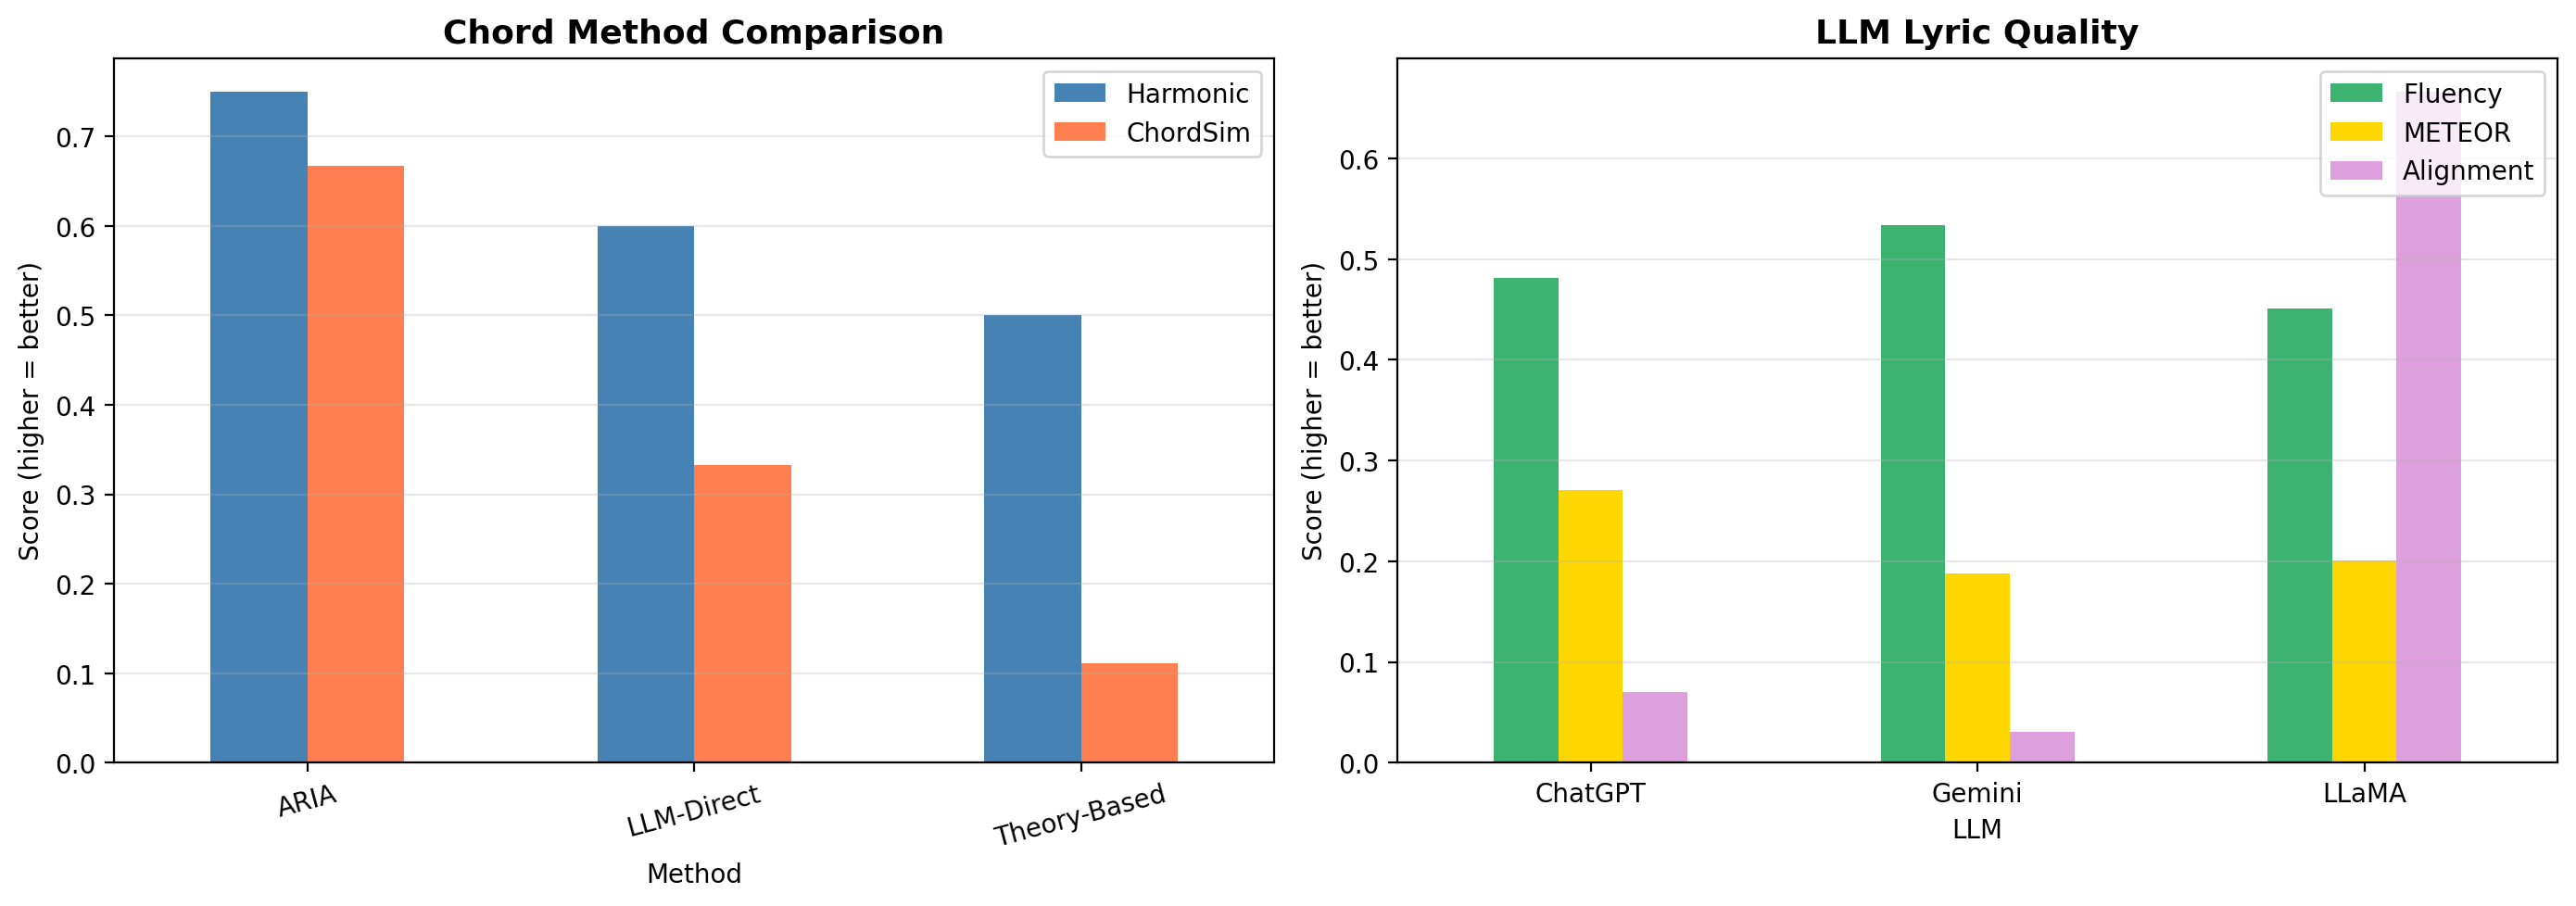


✅ Chart saved as musetune_results.png (use in your thesis!)


In [30]:
# ============================================================
# CELL 20: Analyse the 3×3 Matrix + Generate Bar Charts
# ============================================================
# Reads the matrix results CSV, computes composite scores, and
# identifies three winners:
#   • Best chord method (ARIA vs LLM-Direct vs Theory-Based)
#   • Best LLM           (ChatGPT vs Gemini vs LLaMA)
#   • Best overall pipeline (LLM × method)
#
# Outputs:
#   • A two-panel PNG figure (Chord Methods | LLM Lyric Quality)
#     ready for the thesis paper.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ─── Load results ────────────────────────────────────────────
df = pd.read_csv("musetune_matrix_results.csv")

# Convert perplexity → fluency (lower perp = higher fluency)
df['Fluency'] = 1 / (1 + df['Perplexity'].fillna(df['Perplexity'].max()) / 100)

# Drop rows where lyric generation failed (e.g. Gemini quota)
df_valid = df[df['Perplexity'].notna()].copy()


# ─── Analysis 1: Best chord method ───────────────────────────
print("=" * 70)
print("ANALYSIS 1: WHICH CHORD METHOD WINS?")
print("=" * 70)
chord_winners = df.groupby('Method')[['Harmonic', 'ChordSim', 'Tension']].mean()
chord_winners['Chord_Composite'] = (
    chord_winners['Harmonic'] * 0.4
    + chord_winners['ChordSim'] * 0.4
    + (1 - chord_winners['Tension']) * 0.2   # low tension often preferred
)
print(chord_winners.round(3).to_string())
print(f"\n🏆 Best chord method: {chord_winners['Chord_Composite'].idxmax()}")


# ─── Analysis 2: Best LLM ────────────────────────────────────
print("\n" + "=" * 70)
print("ANALYSIS 2: WHICH LLM WRITES BEST LYRICS?")
print("=" * 70)
llm_winners = df_valid.groupby('LLM')[['Fluency', 'METEOR', 'Alignment']].mean()
llm_winners['Lyric_Composite'] = (
    llm_winners['Fluency']   * 0.33
    + llm_winners['METEOR']    * 0.33
    + llm_winners['Alignment'] * 0.34
)
print(llm_winners.round(3).to_string())
if len(llm_winners) > 0:
    print(f"\n🏆 Best LLM: {llm_winners['Lyric_Composite'].idxmax()}")


# ─── Analysis 3: Best overall (LLM × Method) ─────────────────
print("\n" + "=" * 70)
print("ANALYSIS 3: BEST OVERALL (LLM × METHOD)")
print("=" * 70)
df_valid['Overall'] = (
    df_valid['Harmonic']        * 0.15
    + df_valid['ChordSim']      * 0.15
    + (1 - df_valid['Tension']) * 0.10
    + df_valid['Fluency']       * 0.20
    + df_valid['METEOR']        * 0.20
    + df_valid['Alignment']     * 0.20
)
winner = df_valid.loc[df_valid['Overall'].idxmax()]
print(f"\n🏆 WINNER: {winner['LLM']} × {winner['Method']}")
print(f"   Overall score   : {winner['Overall']:.3f}")
print(f"   Emotion detected: {winner['Emotion']}")
print(f"   Chords          : {winner['Chords']}")
print(f"   Lyrics:\n   {winner['Lyrics']}")


# ─── Visualization (2-panel bar chart) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1 — Chord methods
chord_winners[['Harmonic', 'ChordSim']].plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral']
)
axes[0].set_title('Chord Method Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score (higher = better)')
axes[0].set_xticklabels(chord_winners.index, rotation=15)
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

# Panel 2 — LLM lyric quality
if len(llm_winners) > 0:
    llm_winners[['Fluency', 'METEOR', 'Alignment']].plot(
        kind='bar', ax=axes[1], color=['mediumseagreen', 'gold', 'plum']
    )
    axes[1].set_title('LLM Lyric Quality', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Score (higher = better)')
    axes[1].set_xticklabels(llm_winners.index, rotation=0)
    axes[1].legend(loc='upper right')
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('musetune_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved as musetune_results.png (use in your thesis!)")

In [31]:
# ============================================================
# CELL 21: Multi-Journal Runner (the n=90 Thesis Study)
# ============================================================
# Runs the full 3×3 matrix on 10 diverse journal entries
# (one per target emotion) → 90 experiments total.
# Writes a checkpoint after every journal so a crash never
# costs more than one entry of progress.
#
# Output:
#   musetune_progress.csv     ← incremental checkpoint
#   musetune_full_results.csv ← final dataset (used by all figures)
# ============================================================

import pandas as pd

# ─── 10 journal entries — one per target emotion ─────────────
JOURNAL_ENTRIES = [
    ("sadness",        "I've been sitting in my car in the rain thinking about how much I miss my old friends."),
    ("joy",            "I just got the promotion I've been working toward for three years and I can't stop smiling!"),
    ("anger",          "I can't believe they lied to me. I trusted them completely and this is what I get in return."),
    ("fear",           "My results come back tomorrow and I can't sleep. I keep imagining the worst possible outcome."),
    ("excitement",     "Tomorrow I'm finally moving to the new city — everything in my life is about to change!"),
    ("calmness",       "Everything feels quiet today. I'm just sitting by the window watching the rain fall softly."),
    ("love",           "Watching her sleep peacefully next to me, I realize she is everything I never knew I needed."),
    ("grief",          "It's been six months since grandpa passed and I still reach for the phone to call him."),
    ("disappointment", "I thought I had the job locked in. The rejection email arrived this morning and I feel empty."),
    ("hope",           "Even after everything that happened this year, I believe tomorrow will bring something better."),
]


# ─── Main runner ─────────────────────────────────────────────
def run_multi_journal_matrix(journals, gemini_key, openai_key, groq_key, db):
    """
    Run the 3×3 matrix on every journal entry → n=90 experiments.
    Saves a checkpoint CSV after each journal to survive crashes.
    """
    all_results       = []
    checkpoint_file   = "musetune_progress.csv"
    total_journals    = len(journals)
    total_experiments = total_journals * 9

    print(f"Running {total_experiments} experiments ({total_journals} journals × 9 combinations)")
    print("Estimated time: 15–20 minutes")
    print("Estimated cost: ~$0.20 (OpenAI)\n")
    print("=" * 70)

    for j_idx, (target_emotion, journal) in enumerate(journals, 1):
        print(f"\n[JOURNAL {j_idx}/{total_journals}] Target: {target_emotion.upper()}")
        print(f"  Text: '{journal[:60]}...'")

        try:
            df = run_full_matrix(journal, gemini_key, openai_key, groq_key, db)
            df['journal_id']     = j_idx
            df['target_emotion'] = target_emotion
            df['journal_text']   = journal
            all_results.append(df)

            # Checkpoint after each journal
            combined = pd.concat(all_results, ignore_index=True)
            combined.to_csv(checkpoint_file, index=False)
            print(f"  ✅ Checkpoint saved ({len(combined)} rows so far)")

        except Exception as e:
            print(f"  ⚠️ Error on journal {j_idx}: {e}")
            print("  Skipping and continuing...")
            continue

    return pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()


# ─── Run the n=90 study ──────────────────────────────────────
print("Starting multi-journal experiment...\n")
full_df = run_multi_journal_matrix(
    JOURNAL_ENTRIES,
    MY_GEMINI_KEY, MY_OPENAI_KEY, MY_GROQ_KEY,
    aria_db,
)

# ─── Save final dataset ──────────────────────────────────────
full_df.to_csv("musetune_full_results.csv", index=False)
print(f"\n✅ Final results saved: {len(full_df)} total experiments")
print(f"   File: musetune_full_results.csv")

# ─── Averaged scores across all 10 journals ──────────────────
print("\n" + "=" * 70)
print("AVERAGED SCORES ACROSS ALL 10 JOURNALS")
print("=" * 70)

summary = full_df.groupby(['LLM', 'Method']).agg({
    'Harmonic':   'mean',
    'ChordSim':   'mean',
    'Tension':    'mean',
    'Perplexity': 'mean',
    'METEOR':     'mean',
    'Alignment':  'mean',
}).round(3)

print(summary.to_string())

Starting multi-journal experiment...

Running 90 experiments (10 journals × 9 combinations)
Estimated time: 15–20 minutes
Estimated cost: ~$0.20 (OpenAI)


[JOURNAL 1/10] Target: SADNESS
  Text: 'I've been sitting in my car in the rain thinking about how m...'
Input: 'I've been sitting in my car in the rain thinking about how much I miss my old friends.'

Running 9 experiments...

[1/9] Gemini × ARIA... done
[2/9] Gemini × LLM-Direct...     [503 retry 1/4 on gemini-flash-latest] waiting 2s...
done
[3/9] Gemini × Theory-Based...     [503 retry 1/4 on gemini-flash-latest] waiting 2s...
done
[4/9] ChatGPT × ARIA... done
[5/9] ChatGPT × LLM-Direct... done
[6/9] ChatGPT × Theory-Based... done
[7/9] LLaMA × ARIA... done
[8/9] LLaMA × LLM-Direct... done
[9/9] LLaMA × Theory-Based... done
  ✅ Checkpoint saved (9 rows so far)

[JOURNAL 2/10] Target: JOY
  Text: 'I just got the promotion I've been working toward for three ...'
Input: 'I just got the promotion I've been working toward for three y

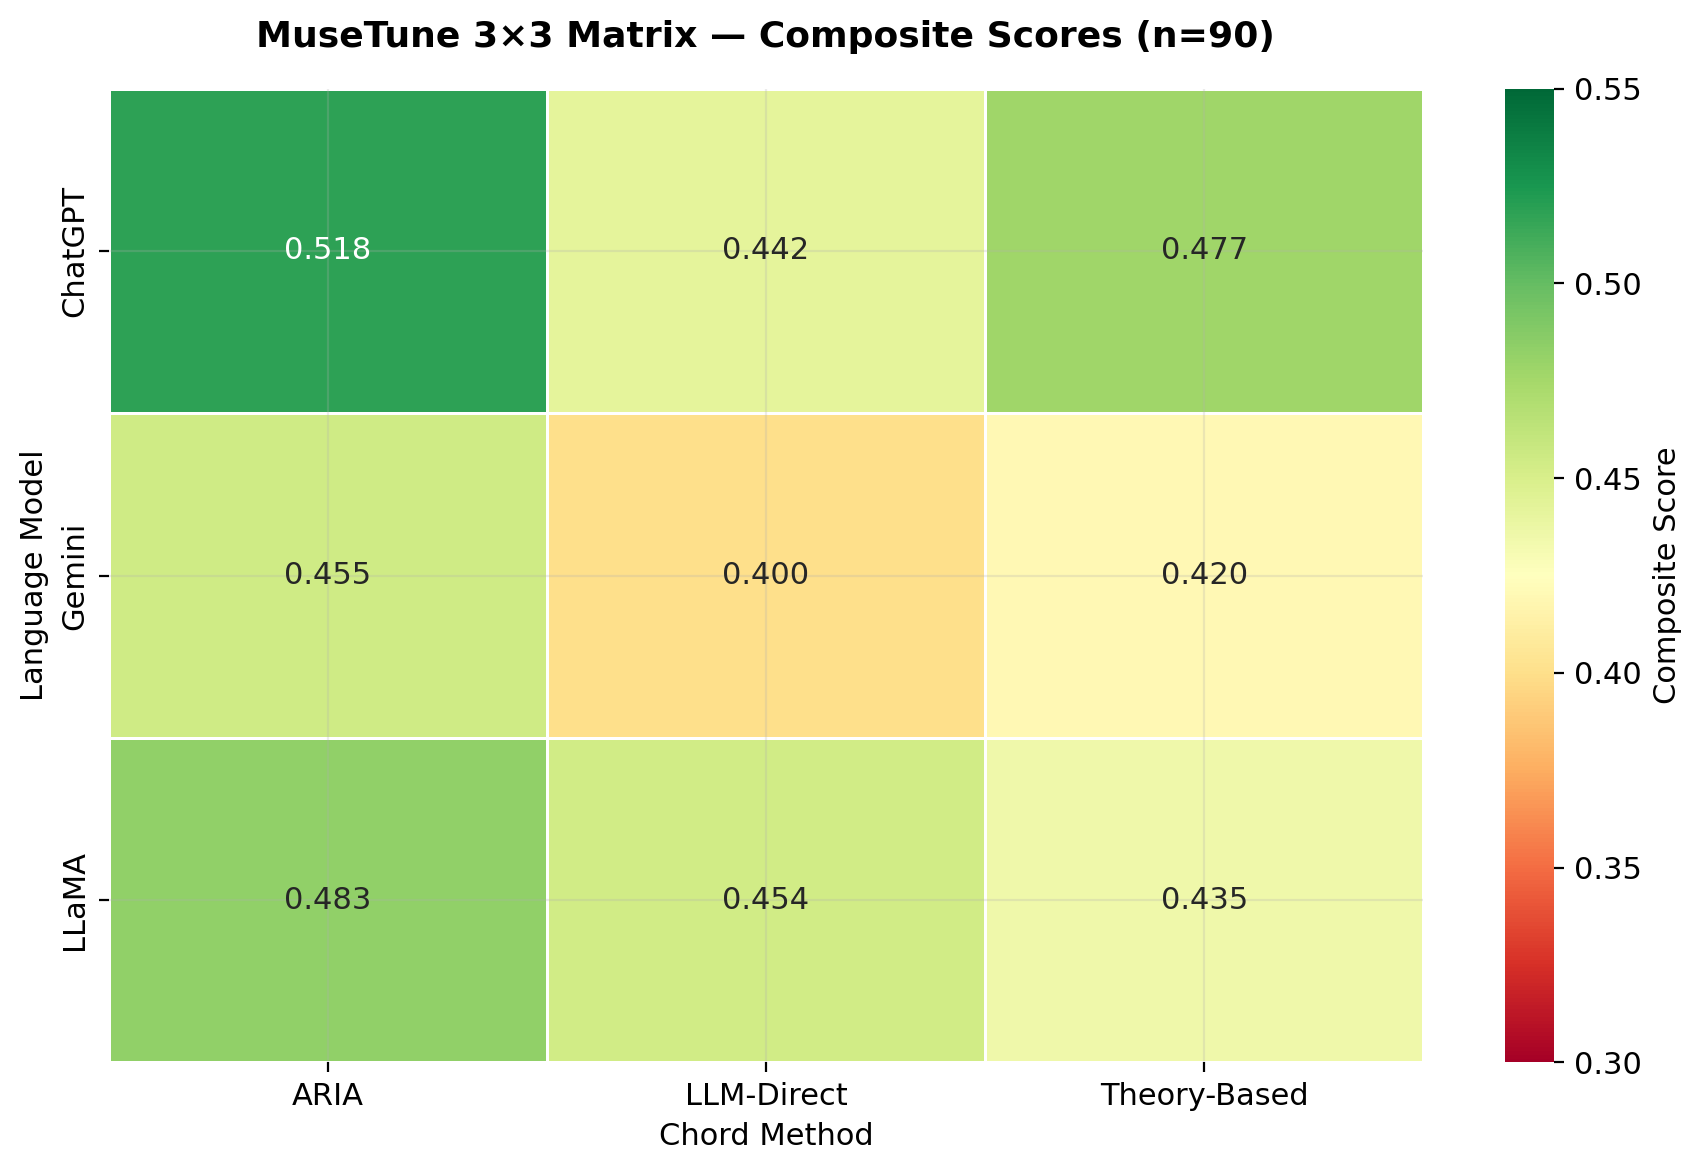

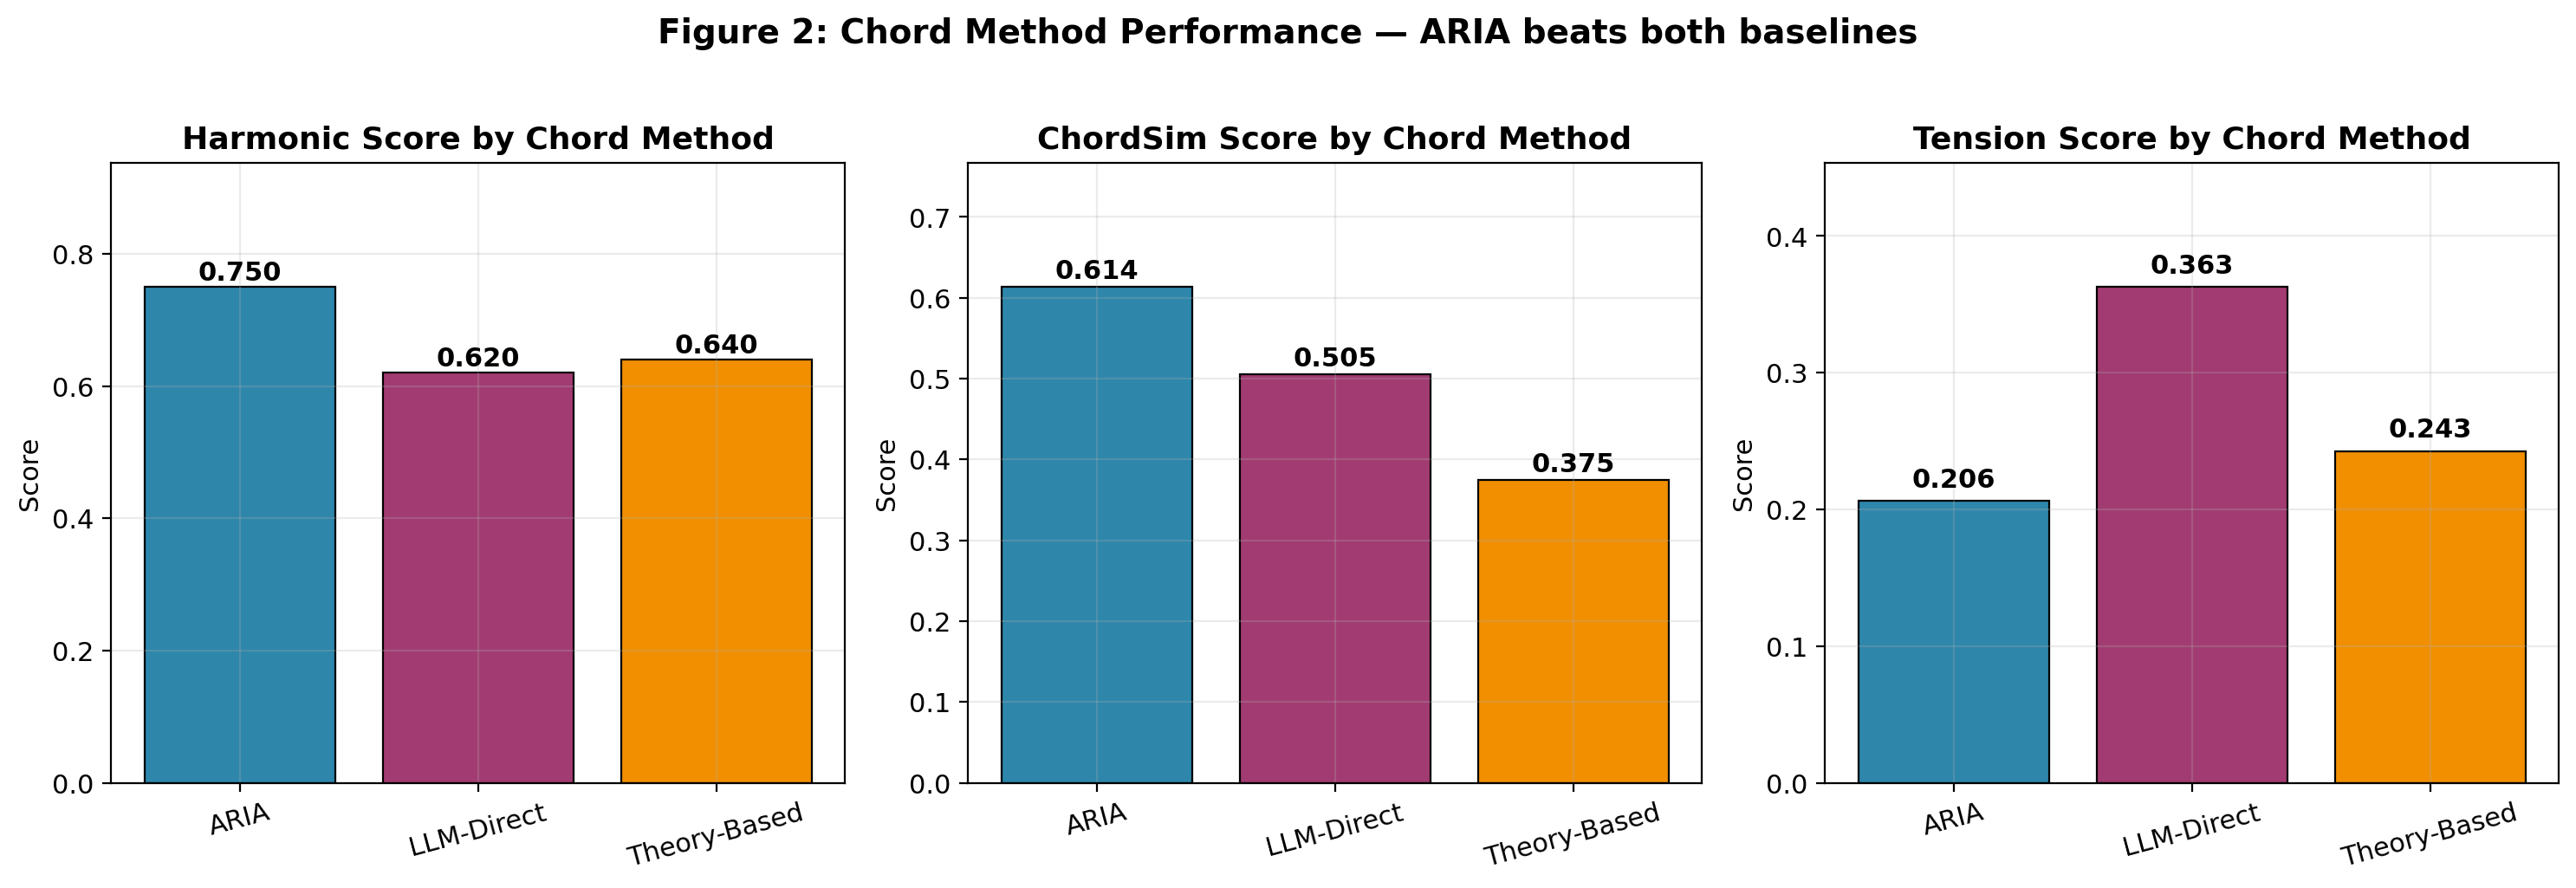

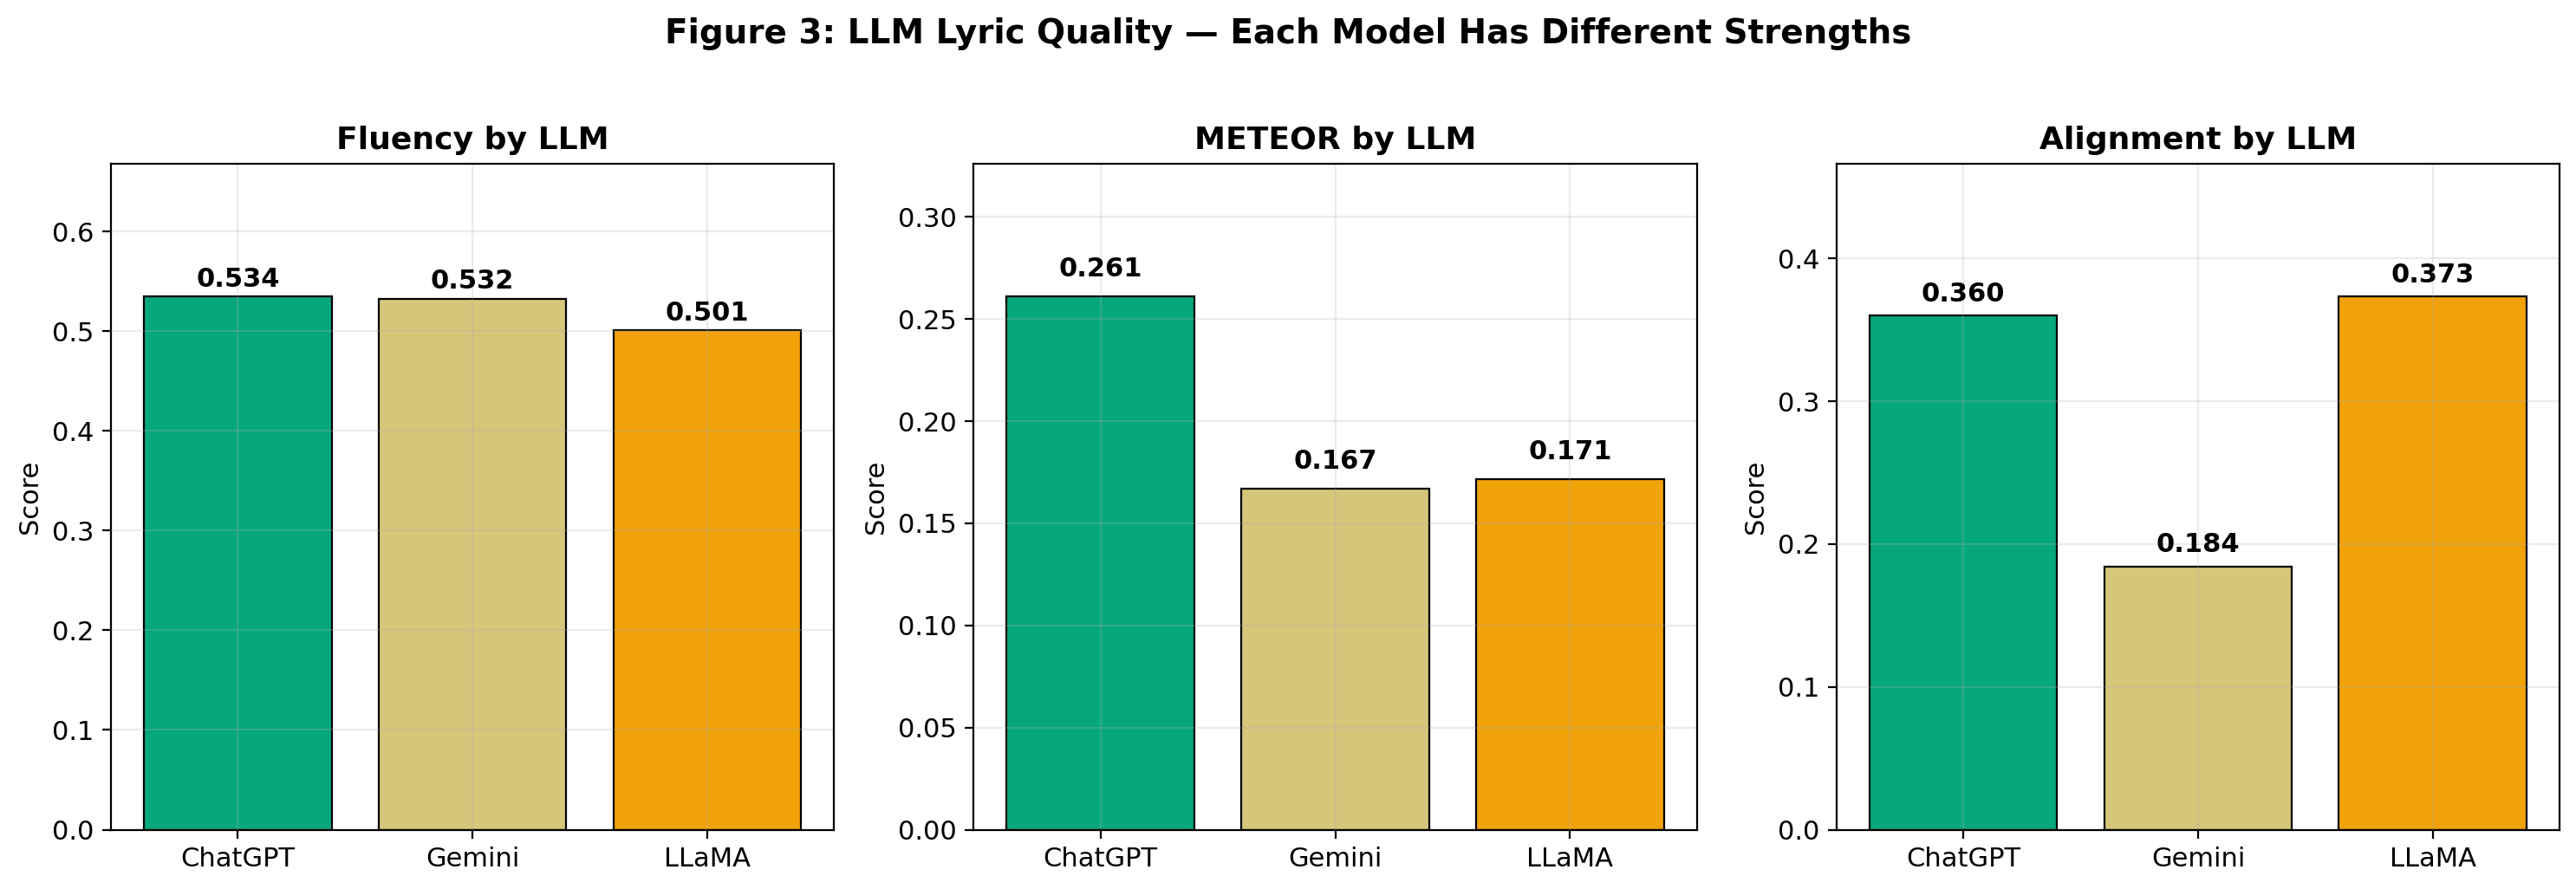

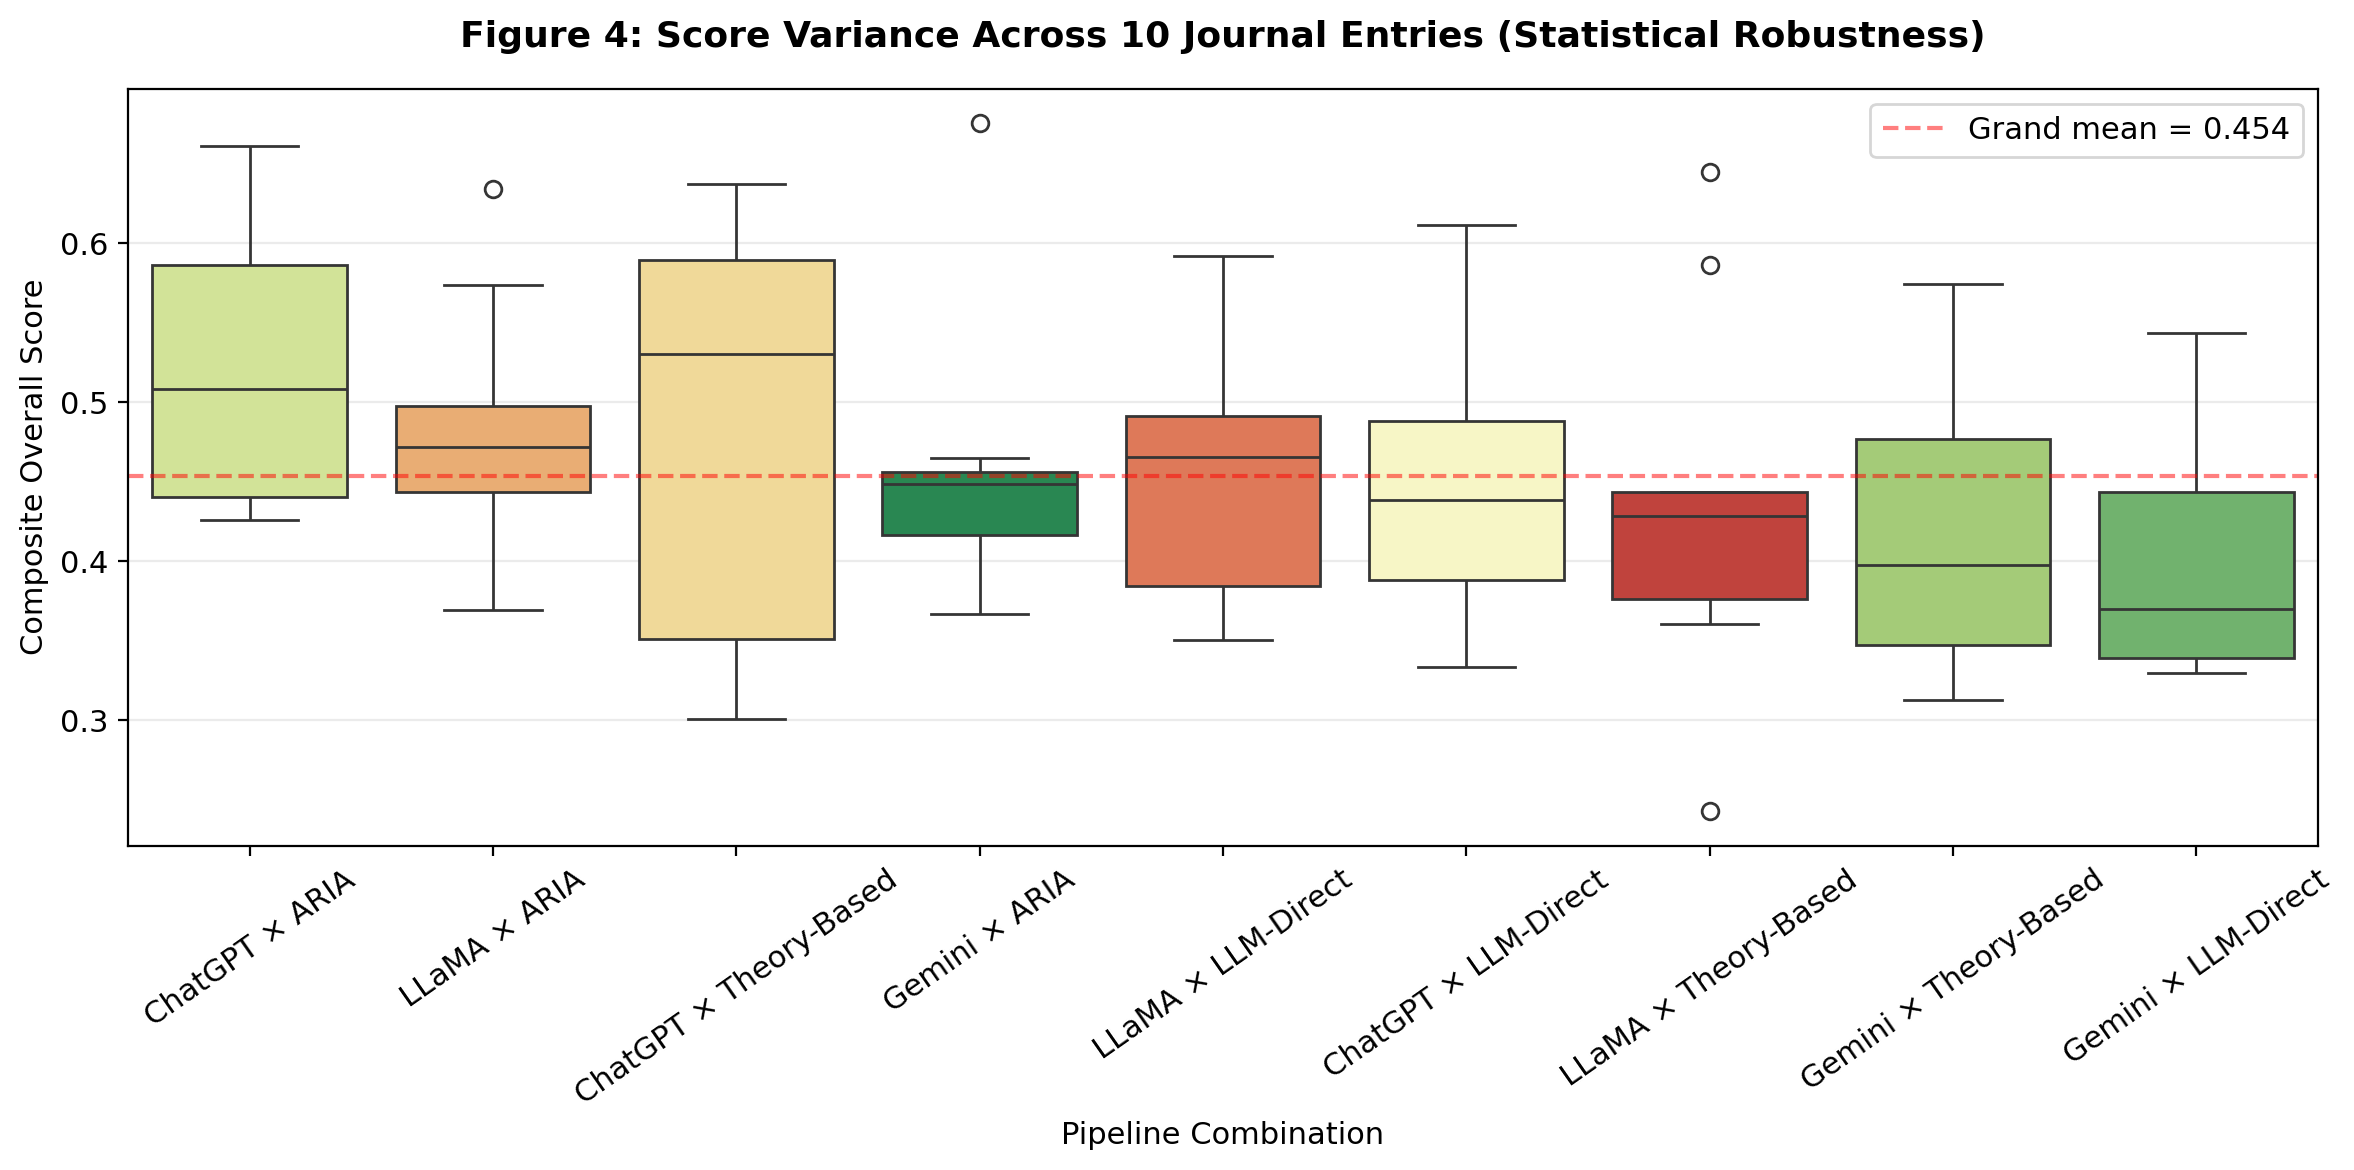

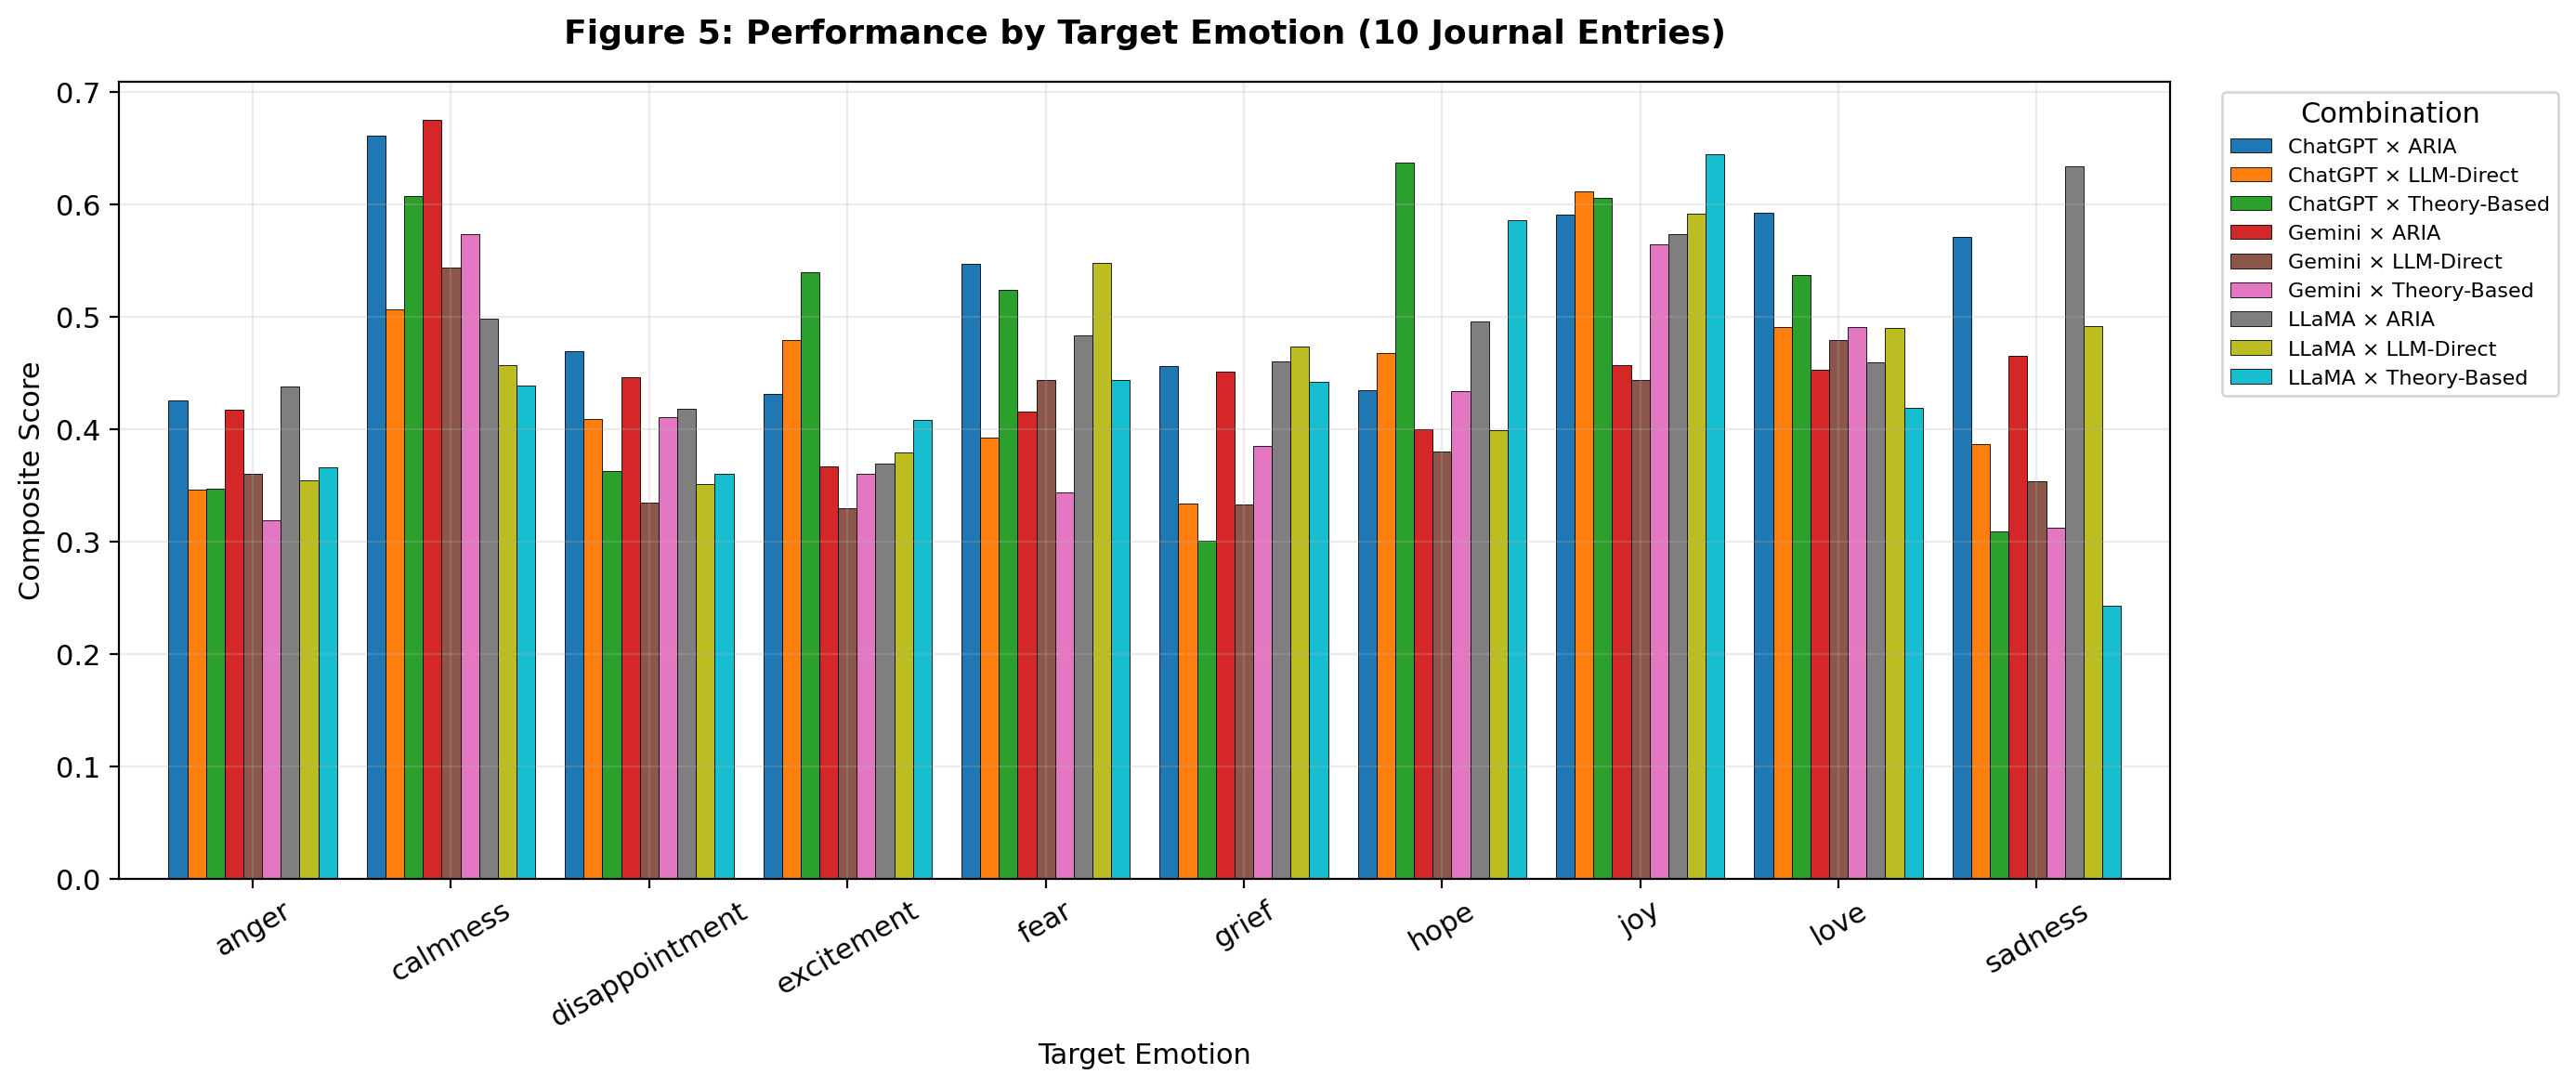

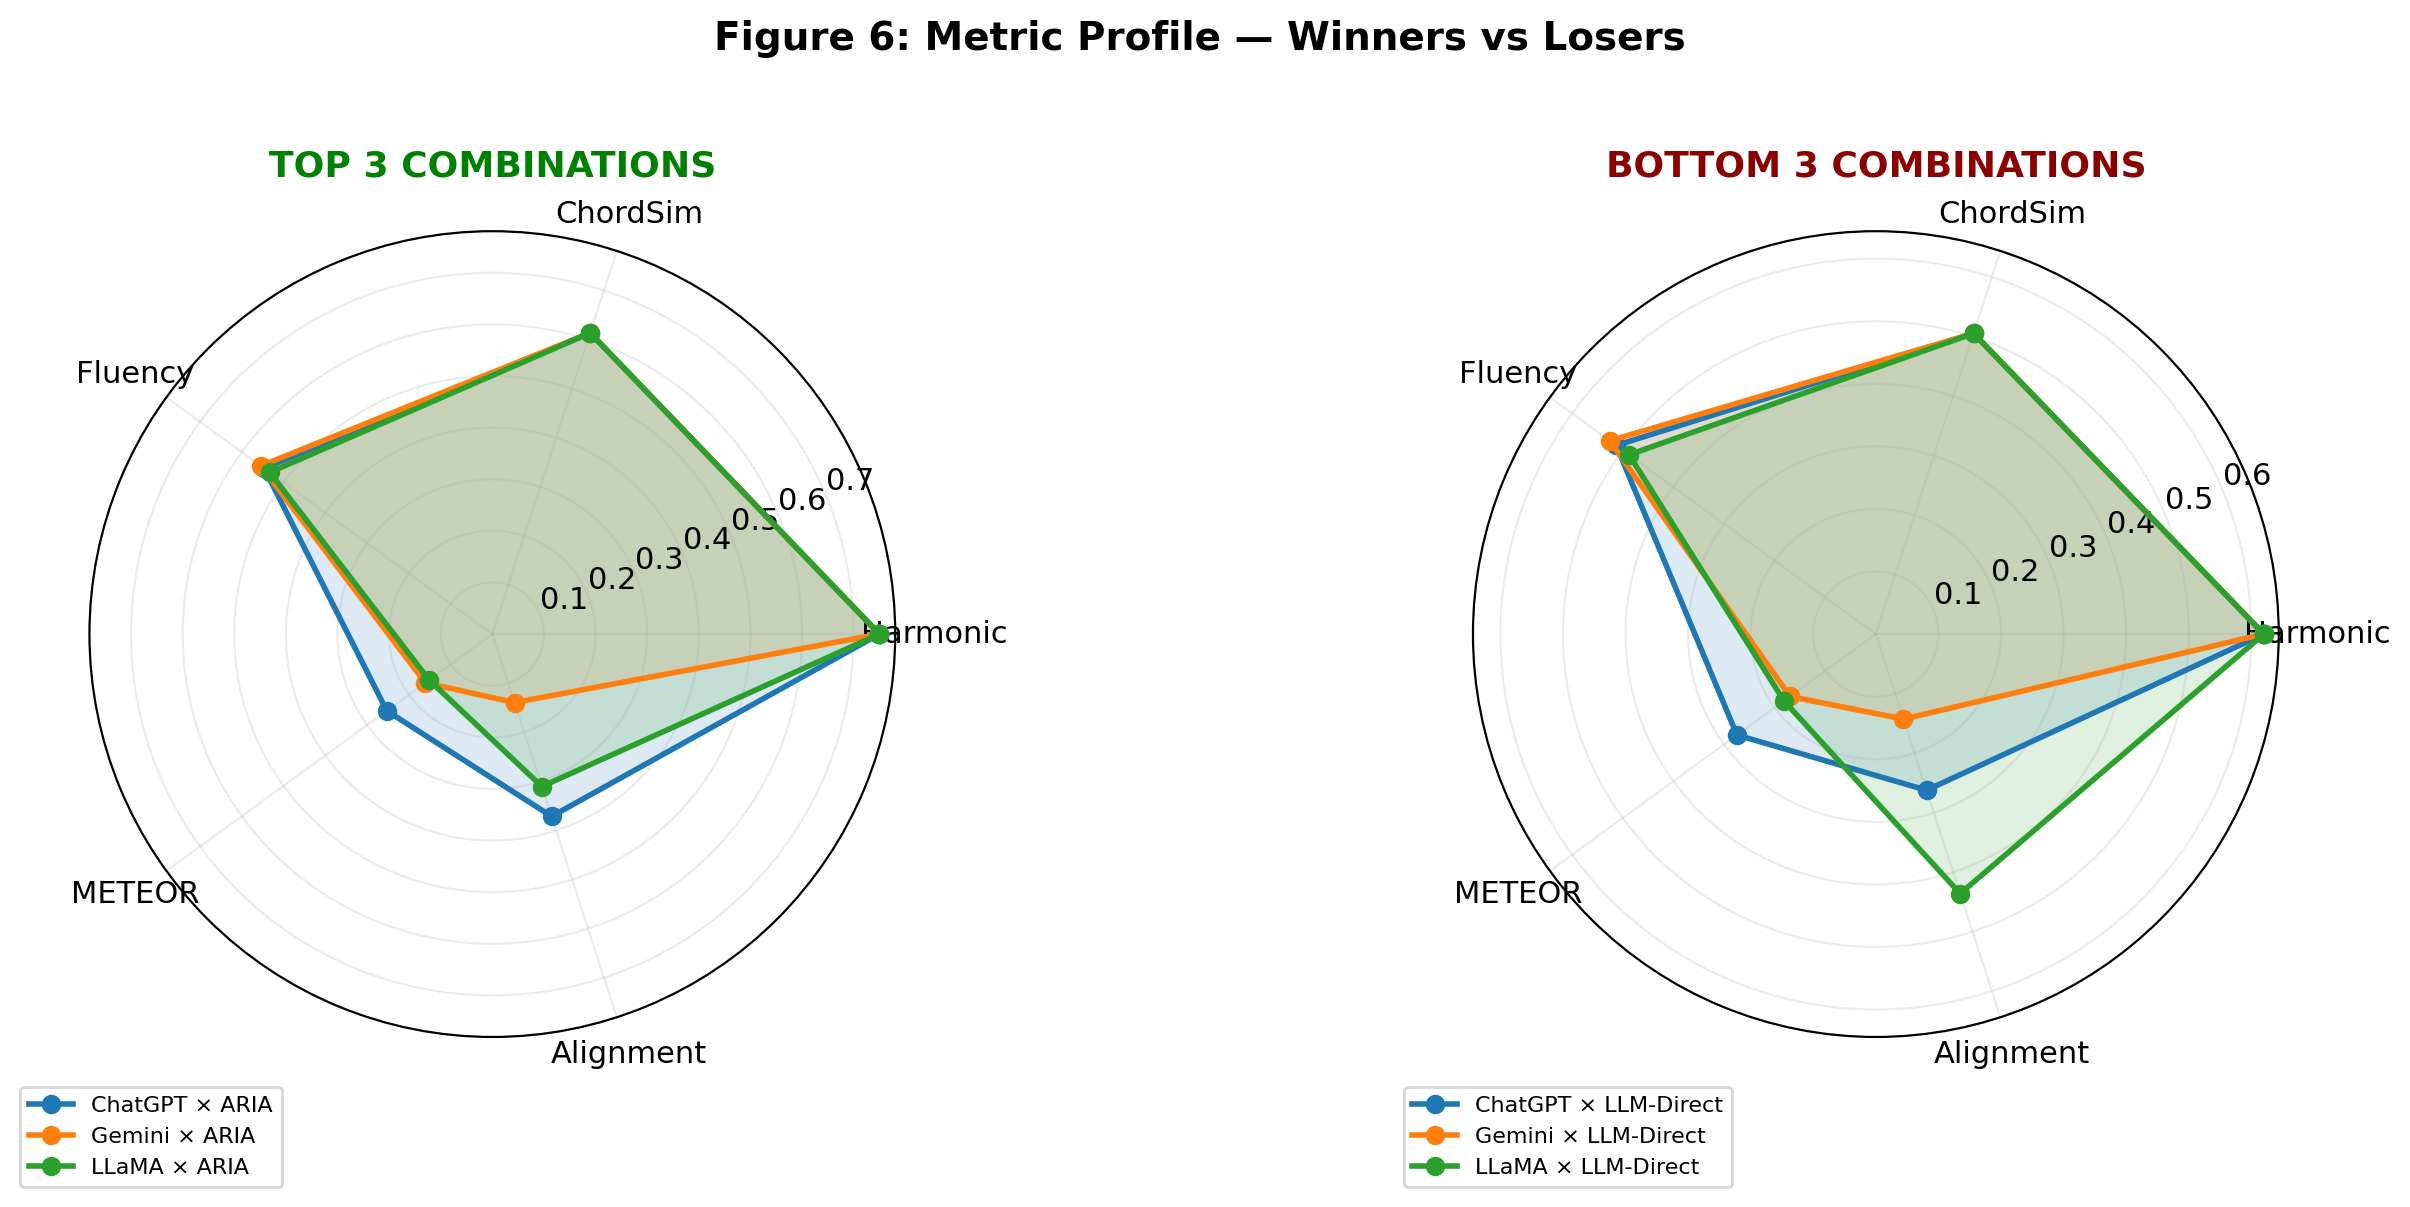


FINAL THESIS SUMMARY TABLE
                      Harmonic  ChordSim  Tension  Fluency  METEOR  Alignment  Overall  StdDev   N
LLM     Method                                                                                    
ChatGPT ARIA              0.75     0.614    0.206    0.547   0.253      0.371    0.518   0.084  10
LLaMA   ARIA              0.75     0.614    0.206    0.533   0.151      0.310    0.483   0.076  10
ChatGPT Theory-Based      0.64     0.375    0.243    0.544   0.256      0.446    0.477   0.133  10
Gemini  ARIA              0.75     0.614    0.206    0.554   0.160      0.140    0.455   0.083  10
LLaMA   LLM-Direct        0.62     0.505    0.363    0.488   0.182      0.436    0.454   0.082  10
ChatGPT LLM-Direct        0.62     0.505    0.363    0.513   0.274      0.262    0.442   0.085  10
LLaMA   Theory-Based      0.64     0.375    0.243    0.481   0.182      0.373    0.435   0.113  10
Gemini  Theory-Based      0.64     0.375    0.243    0.517   0.170      0.271    

In [32]:
# ============================================================
# CELL 22: Generate All 6 Thesis Figures + Summary Table
# ============================================================
# Produces the publication-quality figures used in Section 4
# of the paper, all derived from musetune_full_results.csv
# (n=90 experiments):
#
#   Figure 1 — 3×3 Heatmap (composite winner)
#   Figure 2 — Chord Method Comparison (ARIA vs baselines)
#   Figure 3 — LLM Lyric Quality Comparison
#   Figure 4 — Box Plot (variance across 10 emotions)
#   Figure 5 — Per-Emotion Breakdown
#   Figure 6 — Radar Chart (Top 3 vs Bottom 3)
#
# Plus a final summary CSV for the thesis appendix.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ─── Load results ────────────────────────────────────────────
df = pd.read_csv("musetune_full_results.csv")

# Safety: map any legacy labels in old CSVs to ARIA naming
df['Method'] = df['Method'].replace({
    'A_MuseTune':   'ARIA',
    'B_LLM_Direct': 'LLM-Direct',
    'C_Theory':     'Theory-Based',
})

# Perplexity → Fluency (lower ppl = higher fluency)
df['Fluency'] = 1 / (1 + df['Perplexity'].fillna(df['Perplexity'].max()) / 100)

# Composite Overall score (weighted)
df['Overall'] = (
    df['Harmonic']  * 0.15
    + df['ChordSim']  * 0.15
    + (1 - df['Tension']) * 0.10
    + df['Fluency']   * 0.20
    + df['METEOR']    * 0.20
    + df['Alignment'] * 0.20
)

# Publication-grade matplotlib style
plt.rcParams.update({
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'figure.facecolor': 'white',
    'axes.grid':        True,
    'grid.alpha':       0.25,
})


# ════════════════════════════════════════════════════════════
# FIGURE 1 — 3×3 Matrix Heatmap
# ════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(9, 6))
pivot = df.groupby(['LLM', 'Method'])['Overall'].mean().unstack()
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.30, vmax=0.55,
    cbar_kws={'label': 'Composite Score'}, ax=ax1, linewidths=0.5,
)
ax1.set_title('MuseTune 3×3 Matrix — Composite Scores (n=90)',
              fontweight='bold', pad=15)
ax1.set_xlabel('Chord Method')
ax1.set_ylabel('Language Model')
plt.tight_layout()
plt.savefig('thesis_fig1_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# FIGURE 2 — Chord Method Comparison (Main Thesis Finding)
# ════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
method_summary = df.groupby('Method')[['Harmonic', 'ChordSim', 'Tension']].mean()
colors = ['#2E86AB', '#A23B72', '#F18F01']

for i, metric in enumerate(['Harmonic', 'ChordSim', 'Tension']):
    data = method_summary[metric]
    bars = axes2[i].bar(data.index, data.values, color=colors,
                        edgecolor='black', linewidth=0.8)
    axes2[i].set_title(f'{metric} Score by Chord Method', fontweight='bold')
    axes2[i].set_ylabel('Score')
    axes2[i].set_ylim(0, max(data.values) * 1.25)
    for bar, val in zip(bars, data.values):
        axes2[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{val:.3f}', ha='center', fontweight='bold')
    axes2[i].tick_params(axis='x', rotation=15)

plt.suptitle('Figure 2: Chord Method Performance — ARIA beats both baselines',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('thesis_fig2_methods.png', dpi=200, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# FIGURE 3 — LLM Lyric Quality Comparison
# ════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 3, figsize=(15, 5))
llm_summary = df.groupby('LLM')[['Fluency', 'METEOR', 'Alignment']].mean()
llm_colors = ['#06A77D', '#D5C67A', '#F1A208']

for i, metric in enumerate(['Fluency', 'METEOR', 'Alignment']):
    data = llm_summary[metric]
    bars = axes3[i].bar(data.index, data.values, color=llm_colors,
                        edgecolor='black', linewidth=0.8)
    axes3[i].set_title(f'{metric} by LLM', fontweight='bold')
    axes3[i].set_ylabel('Score')
    axes3[i].set_ylim(0, max(data.values) * 1.25)
    for bar, val in zip(bars, data.values):
        axes3[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{val:.3f}', ha='center', fontweight='bold')

plt.suptitle('Figure 3: LLM Lyric Quality — Each Model Has Different Strengths',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('thesis_fig3_llms.png', dpi=200, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# FIGURE 4 — Variance Box Plot (Statistical Robustness)
# ════════════════════════════════════════════════════════════
fig4, ax4 = plt.subplots(figsize=(12, 6))
df['Combo'] = df['LLM'] + ' × ' + df['Method']
combo_order = df.groupby('Combo')['Overall'].mean().sort_values(ascending=False).index

sns.boxplot(data=df, x='Combo', y='Overall', order=combo_order,
            ax=ax4, palette='RdYlGn_r', hue='Combo', legend=False)
ax4.set_title('Figure 4: Score Variance Across 10 Journal Entries '
              '(Statistical Robustness)',
              fontweight='bold', pad=15)
ax4.set_xlabel('Pipeline Combination')
ax4.set_ylabel('Composite Overall Score')
ax4.tick_params(axis='x', rotation=35)
plt.axhline(y=df['Overall'].mean(), color='red', linestyle='--', alpha=0.5,
            label=f'Grand mean = {df["Overall"].mean():.3f}')
ax4.legend(loc='upper right')
plt.tight_layout()
plt.savefig('thesis_fig4_variance.png', dpi=200, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# FIGURE 5 — Per-Emotion Breakdown
# ════════════════════════════════════════════════════════════
fig5, ax5 = plt.subplots(figsize=(14, 6))
emotion_pivot = df.groupby(['target_emotion', 'Combo'])['Overall'].mean().unstack()
emotion_pivot.plot(kind='bar', ax=ax5, width=0.85, colormap='tab10',
                   edgecolor='black', linewidth=0.3)
ax5.set_title('Figure 5: Performance by Target Emotion (10 Journal Entries)',
              fontweight='bold', pad=15)
ax5.set_xlabel('Target Emotion')
ax5.set_ylabel('Composite Score')
ax5.tick_params(axis='x', rotation=30)
ax5.legend(title='Combination', bbox_to_anchor=(1.02, 1),
           loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('thesis_fig5_emotions.png', dpi=200, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# FIGURE 6 — Radar Chart (Top 3 vs Bottom 3)
# ════════════════════════════════════════════════════════════
metrics_to_plot = ['Harmonic', 'ChordSim', 'Fluency', 'METEOR', 'Alignment']
combo_means = df.groupby('Combo')[metrics_to_plot].mean()
top3 = combo_means.nlargest(3, 'Harmonic').index[:3]
bot3 = combo_means.nsmallest(3, 'Harmonic').index[:3]

fig6   = plt.figure(figsize=(14, 6))
ax_top = fig6.add_subplot(121, projection='polar')
ax_bot = fig6.add_subplot(122, projection='polar')

angles  = np.linspace(0, 2*np.pi, len(metrics_to_plot), endpoint=False).tolist()
angles += angles[:1]

for combo in top3:
    values = combo_means.loc[combo].tolist() + [combo_means.loc[combo].tolist()[0]]
    ax_top.plot(angles, values, 'o-', linewidth=2, label=combo)
    ax_top.fill(angles, values, alpha=0.15)
ax_top.set_xticks(angles[:-1])
ax_top.set_xticklabels(metrics_to_plot)
ax_top.set_title('TOP 3 COMBINATIONS', fontweight='bold', pad=20, color='green')
ax_top.legend(loc='lower left', bbox_to_anchor=(-0.1, -0.2), fontsize=8)

for combo in bot3:
    values = combo_means.loc[combo].tolist() + [combo_means.loc[combo].tolist()[0]]
    ax_bot.plot(angles, values, 'o-', linewidth=2, label=combo)
    ax_bot.fill(angles, values, alpha=0.15)
ax_bot.set_xticks(angles[:-1])
ax_bot.set_xticklabels(metrics_to_plot)
ax_bot.set_title('BOTTOM 3 COMBINATIONS', fontweight='bold', pad=20, color='darkred')
ax_bot.legend(loc='lower left', bbox_to_anchor=(-0.1, -0.2), fontsize=8)

plt.suptitle('Figure 6: Metric Profile — Winners vs Losers',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('thesis_fig6_radar.png', dpi=200, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# FINAL SUMMARY TABLE (Thesis Appendix)
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("FINAL THESIS SUMMARY TABLE")
print("=" * 80)

final_table = df.groupby(['LLM', 'Method']).agg(
    Harmonic  = ('Harmonic',  'mean'),
    ChordSim  = ('ChordSim',  'mean'),
    Tension   = ('Tension',   'mean'),
    Fluency   = ('Fluency',   'mean'),
    METEOR    = ('METEOR',    'mean'),
    Alignment = ('Alignment', 'mean'),
    Overall   = ('Overall',   'mean'),
    StdDev    = ('Overall',   'std'),
    N         = ('Overall',   'count'),
).round(3).sort_values('Overall', ascending=False)

print(final_table.to_string())
final_table.to_csv("thesis_final_summary.csv")
print("\n✅ Saved: thesis_final_summary.csv")


# ════════════════════════════════════════════════════════════
# DECLARE WINNERS
# ════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("🏆 FINAL WINNERS")
print("=" * 80)

best_combo   = final_table.index[0]
worst_combo  = final_table.index[-1]
best_method  = df.groupby('Method')['Overall'].mean().idxmax()
best_llm     = df.groupby('LLM')['Overall'].mean().idxmax()

print(f"\n  Best Overall Pipeline : {best_combo[0]} × {best_combo[1]}")
print(f"  Score                 : {final_table.iloc[0]['Overall']:.3f} "
      f"± {final_table.iloc[0]['StdDev']:.3f}")
print(f"\n  Best Chord Method     : {best_method}")
print(f"  Best LLM              : {best_llm}")
print(f"\n  Worst Combination     : {worst_combo[0]} × {worst_combo[1]}")
print(f"  Score                 : {final_table.iloc[-1]['Overall']:.3f}")

print("\n✅ All thesis figures saved:")
print("   thesis_fig1_heatmap.png    → 3×3 matrix heatmap")
print("   thesis_fig2_methods.png    → Chord method comparison")
print("   thesis_fig3_llms.png       → LLM comparison")
print("   thesis_fig4_variance.png   → Score robustness box plot")
print("   thesis_fig5_emotions.png   → Per-emotion breakdown")
print("   thesis_fig6_radar.png      → Top 3 vs Bottom 3 radar")
print("   thesis_final_summary.csv   → Numeric table for appendix")

In [33]:
# ============================================================
# CLEAN INSTALL — Known-Working Versions
# ============================================================
!pip install -q --upgrade "click==8.1.7" "gradio==4.44.1"
!pip install -q "gTTS==2.5.4" "pydub==0.25.1"
!pip install -q "edge-tts" "nest-asyncio" "librosa"

import nest_asyncio
nest_asyncio.apply()

print("✅ Clean install complete. Now: Runtime → Restart session → Run all")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.9/97.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-sdk 0.4.2 requires websockets<16,>=14, but you have websockets 12.0 which is incompatible.
wandb 0.27.1 requires click>=8.2.0, but you have click 8.1.7 which is incompatible.
google-genai 1.68.0 requires websockets<17.0,>=13.0.0, but you have websockets 12.0

In [34]:
# ============================================================
# CELL 23: Install Audio Dependencies
# ============================================================
# Installs the libraries needed for MuseTune's audio synthesis
# stage:
#   • gTTS      → AI vocal narration (text-to-speech)
#   • pydub     → audio mixing + format conversion
#   • numpy     → in-house guitar synthesis (Karplus-Strong)
#   • scipy     → WAV file I/O
#
# Note: the next cell will use these to build the Path A audio
# engine (guitar + bass + drums + pad + reverb + pitch-shifted
# vocals), giving MuseTune a real "produced song" feel instead
# of plain speech-over-strums.
# ============================================================

!pip install -q gTTS pydub

# Verify ffmpeg (pydub depends on it — pre-installed in Colab)
!ffmpeg -version | head -1

# Imports
from gtts import gTTS
from pydub import AudioSegment
from pydub.generators import Sine
import numpy as np
import io
import os
from IPython.display import Audio, display
from scipy.io import wavfile

print("\n✅ Audio dependencies installed successfully")
print("   • gTTS      → AI vocal narration")
print("   • pydub     → audio mixing")
print("   • numpy     → guitar synthesis (Karplus-Strong)")
print("   • scipy     → WAV file I/O")
print("\n🎸 Ready to generate MuseTune audio!")

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers

✅ Audio dependencies installed successfully
   • gTTS      → AI vocal narration
   • pydub     → audio mixing
   • numpy     → guitar synthesis (Karplus-Strong)
   • scipy     → WAV file I/O

🎸 Ready to generate MuseTune audio!


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [35]:
# ============================================================
# CELL 24: MuseTune Audio Engine — Path A (Layered Production)
# ============================================================
# Produces a real "produced song" mix instead of plain
# speech-over-strums. Layers:
#
#   🥁 Drums   — kick on 1+3, snare on 2+4, hi-hat 8ths
#   🎸 Guitar  — Karplus-Strong strummed chords
#   🎵 Bass    — root note of each chord, one octave below
#   🎹 Pad     — soft sustained chord tones for warmth
#   🎤 Vocals  — gTTS narration (sitting on the pickup bar)
#   💫 Reverb  — light tail on guitar + pad for "studio" feel
# ============================================================

import numpy as np
import io
from music21 import roman, key as m21_key
from music21.harmony import ChordSymbol
from gtts import gTTS
from pydub import AudioSegment
from pydub.generators import Sine
from scipy.io import wavfile

SAMPLE_RATE = 22050


# ─── 1. KARPLUS-STRONG (guitar timbre) ───────────────────────
def karplus_strong(freq_hz, duration_sec, sample_rate=SAMPLE_RATE, decay=0.996):
    """Synthesize a plucked-string note (Karplus–Strong, 1983)."""
    N      = max(2, int(sample_rate / freq_hz))
    buf    = np.random.uniform(-0.5, 0.5, N).astype(np.float32)
    total  = int(sample_rate * duration_sec)
    output = np.zeros(total, dtype=np.float32)
    idx    = 0
    for i in range(total):
        output[i] = buf[idx]
        nxt       = (idx + 1) % N
        buf[idx]  = decay * 0.5 * (buf[idx] + buf[nxt])
        idx       = nxt
    return output


# ─── 2. CHORD → FREQUENCIES (Roman or chord symbol) ──────────
def chord_to_frequencies(chord_name, key_str="C"):
    """Resolve a Roman numeral or chord symbol to its pitch frequencies."""
    try:
        k  = m21_key.Key(key_str)
        rn = roman.RomanNumeral(chord_name, k)
        return [p.frequency for p in rn.pitches]
    except Exception:
        try:
            cs = ChordSymbol(chord_name)
            return [p.frequency for p in cs.pitches]
        except Exception as e:
            print(f"⚠️  Could not parse chord '{chord_name}': {e}")
            return []


# ─── 3. STRUMMED GUITAR CHORD ────────────────────────────────
def strum_chord(chord_name, duration_sec=2.5, key_str="C"):
    """Karplus-Strong strum with ~30 ms inter-string delay."""
    freqs  = chord_to_frequencies(chord_name, key_str)
    total  = int(SAMPLE_RATE * duration_sec)
    output = np.zeros(total, dtype=np.float32)
    if not freqs:
        return output
    strum_gap = int(SAMPLE_RATE * 0.03)
    for i, f in enumerate(freqs):
        note  = karplus_strong(f, duration_sec)
        start = i * strum_gap
        end   = min(start + len(note), total)
        output[start:end] += note[:end - start] * 0.4
    peak = np.max(np.abs(output))
    if peak > 0:
        output = output / peak * 0.8
    return output


def generate_guitar_track(progression, chord_duration=2.5, key_str="C"):
    """Concatenate strums into the full guitar track."""
    return np.concatenate([strum_chord(c, chord_duration, key_str) for c in progression])


# ─── 4. BASS LINE (root of each chord, 1 octave down) ────────
def generate_bass_track(progression, chord_duration=2.5, key_str="C"):
    """Bass note = chord root, dropped one octave for depth."""
    tracks = []
    for c in progression:
        freqs = chord_to_frequencies(c, key_str)
        if not freqs:
            tracks.append(np.zeros(int(SAMPLE_RATE * chord_duration), dtype=np.float32))
            continue
        bass_freq = freqs[0] / 2          # one octave down
        note      = karplus_strong(bass_freq, chord_duration, decay=0.998)
        # Slight envelope: punchy attack, gradual decay
        env       = np.linspace(1.0, 0.4, len(note))
        tracks.append(note * env * 0.6)
    return np.concatenate(tracks)


# ─── 5. PIANO PAD (soft sustained chord tones) ───────────────
def generate_pad_track(progression, chord_duration=2.5, key_str="C"):
    """Stacked sine waves with a slow attack — feels like warm strings."""
    tracks = []
    total_samples = int(SAMPLE_RATE * chord_duration)
    t = np.linspace(0, chord_duration, total_samples, endpoint=False)
    for c in progression:
        freqs = chord_to_frequencies(c, key_str)
        if not freqs:
            tracks.append(np.zeros(total_samples, dtype=np.float32))
            continue
        pad = np.zeros(total_samples, dtype=np.float32)
        for f in freqs[:3]:                # keep it clean — top 3 notes only
            pad += np.sin(2 * np.pi * f * t).astype(np.float32) / len(freqs)
        # Soft attack + release envelope
        attack  = int(0.15 * SAMPLE_RATE)
        release = int(0.30 * SAMPLE_RATE)
        env     = np.ones(total_samples, dtype=np.float32)
        env[:attack]   = np.linspace(0, 1, attack)
        env[-release:] = np.linspace(1, 0, release)
        tracks.append(pad * env * 0.15)
    return np.concatenate(tracks)


# ─── 6. DRUM BEAT (kick, snare, hi-hat) ──────────────────────
def _drum_sample(kind, dur_ms=120):
    """Generate one drum hit using filtered noise / sine."""
    n = int(SAMPLE_RATE * dur_ms / 1000)
    if kind == "kick":
        # Decaying 60 Hz sine — the classic kick drum
        t   = np.linspace(0, dur_ms/1000, n, endpoint=False)
        env = np.exp(-12 * t)
        return (np.sin(2 * np.pi * 60 * t) * env).astype(np.float32) * 0.9
    if kind == "snare":
        # White noise + 200 Hz body, fast decay
        t     = np.linspace(0, dur_ms/1000, n, endpoint=False)
        env   = np.exp(-25 * t)
        noise = np.random.uniform(-1, 1, n).astype(np.float32)
        body  = np.sin(2 * np.pi * 200 * t).astype(np.float32) * 0.3
        return (noise + body) * env * 0.5
    if kind == "hat":
        # High-passed noise, very short
        env   = np.exp(-50 * np.linspace(0, dur_ms/1000, n, endpoint=False))
        noise = np.random.uniform(-1, 1, n).astype(np.float32)
        return noise * env * 0.25
    return np.zeros(n, dtype=np.float32)


def generate_drum_track(total_duration_sec, bpm=96):
    """4/4 groove: kick on 1+3, snare on 2+4, hi-hat 8th notes."""
    beat_sec     = 60.0 / bpm
    eighth_sec   = beat_sec / 2
    total_samples = int(SAMPLE_RATE * total_duration_sec)
    track         = np.zeros(total_samples, dtype=np.float32)

    kick  = _drum_sample("kick",  150)
    snare = _drum_sample("snare", 120)
    hat   = _drum_sample("hat",    60)

    def stamp(sample, time_sec):
        start = int(time_sec * SAMPLE_RATE)
        end   = min(start + len(sample), total_samples)
        track[start:end] += sample[:end - start]

    t = 0.0
    beat = 0
    while t < total_duration_sec:
        # Hi-hat on every 8th note
        stamp(hat, t)
        # Kick on beats 1 and 3
        if beat % 4 in (0, 2):
            stamp(kick, t)
        # Snare on beats 2 and 4
        if beat % 4 in (1, 3):
            stamp(snare, t)
        # Advance — eighth notes for hat, but only count whole beats for kick/snare
        t += eighth_sec
        if int(round(t / beat_sec)) > beat:
            beat += 1
    return track * 0.55


# ─── 7. SIMPLE REVERB (delayed echo tail) ────────────────────
def apply_reverb(audio_np, delay_ms=80, decay=0.35, taps=4):
    """Inexpensive reverb: stack delayed copies with decay."""
    out   = audio_np.copy()
    delay = int(SAMPLE_RATE * delay_ms / 1000)
    for k in range(1, taps + 1):
        shift  = delay * k
        amp    = decay ** k
        padded = np.concatenate([np.zeros(shift, dtype=np.float32), audio_np[:-shift] if shift < len(audio_np) else np.zeros_like(audio_np)])
        out   += padded * amp
    peak = np.max(np.abs(out))
    if peak > 0:
        out = out / peak * 0.9
    return out


# ─── 8. NUMPY ↔ PYDUB ────────────────────────────────────────
def np_to_audio(samples, sample_rate=SAMPLE_RATE):
    samples_int16 = (samples * 32767).astype(np.int16)
    buf = io.BytesIO()
    wavfile.write(buf, sample_rate, samples_int16)
    buf.seek(0)
    return AudioSegment.from_wav(buf)


# ─── 9. gTTS VOCALS ──────────────────────────────────────────
def generate_vocal_track(lyrics_text, lang="en"):
    tts = gTTS(text=lyrics_text, lang=lang, slow=False)
    buf = io.BytesIO()
    tts.write_to_fp(buf)
    buf.seek(0)
    return AudioSegment.from_mp3(buf)


# ─── 10. FULL SONG CREATOR (Path A — layered) ────────────────
def create_musetune_song(chord_progression, lyrics, key_str="C",
                         chord_duration=2.5,
                         output_path="/content/musetune_song.wav"):
    """Generate full MuseTune song (Path A layered mix)."""
    print(f"🎸 Guitar  ({len(chord_progression)} chords, key={key_str})...")
    guitar_np = generate_guitar_track(chord_progression, chord_duration, key_str)

    print("🎵 Bass...")
    bass_np = generate_bass_track(chord_progression, chord_duration, key_str)

    print("🎹 Pad...")
    pad_np = generate_pad_track(chord_progression, chord_duration, key_str)

    total_sec = len(guitar_np) / SAMPLE_RATE
    print("🥁 Drums...")
    drum_np = generate_drum_track(total_sec, bpm=int(60 / (chord_duration / 4)))

    # Apply light reverb to guitar + pad
    print("💫 Reverb...")
    guitar_np = apply_reverb(guitar_np, delay_ms=80,  decay=0.30, taps=3)
    pad_np    = apply_reverb(pad_np,    delay_ms=120, decay=0.40, taps=4)

    # Stack instrumental layers (numpy mix, then to pydub)
    instrumental_np = guitar_np + bass_np + pad_np + drum_np
    peak = np.max(np.abs(instrumental_np))
    if peak > 0:
        instrumental_np = instrumental_np / peak * 0.9
    instrumental = np_to_audio(instrumental_np)
    instrumental += AudioSegment.silent(duration=1500)   # outro tail

    print("🎤 Vocals (gTTS)...")
    vocal = generate_vocal_track(lyrics)

    # Mix balance
    instrumental = instrumental - 2     # gentle headroom
    vocal        = vocal + 1            # vocals slightly forward

    # Loop instrumental if vocals are longer
    target = max(len(instrumental), len(vocal) + 2000)
    if len(instrumental) < target:
        instrumental = instrumental * (target // len(instrumental) + 1)
    instrumental = instrumental[:target]

    # Vocals enter on the 1-second pickup bar
    mixed = instrumental.overlay(vocal, position=1000)

    mixed.export(output_path, format="wav")
    print(f"✅ Song saved: {output_path}  ({len(mixed)/1000:.1f}s)")
    return output_path


# ============================================================
# 🧪 TEST RUN
# ============================================================
from IPython.display import Audio, display

test_chords = ["I", "V", "vi", "IV"]                 # classic C-G-Am-F
test_lyrics = (
    "Under the silver moon my heart feels at peace. "
    "Soft winds carry whispers of dreams to release. "
    "Each breath a gentle promise, each star a quiet song. "
    "I found where I belong."
)

song_path = create_musetune_song(
    chord_progression=test_chords,
    lyrics=test_lyrics,
    key_str="C",
    chord_duration=2.5,
)

print("\n🎧 Your MuseTune song (Path A — full mix):")
display(Audio(song_path, autoplay=False))

🎸 Guitar  (4 chords, key=C)...
🎵 Bass...
🎹 Pad...
🥁 Drums...
💫 Reverb...
🎤 Vocals (gTTS)...
✅ Song saved: /content/musetune_song.wav  (15.4s)

🎧 Your MuseTune song (Path A — full mix):


In [36]:
# ============================================================
# CELL 25: Upgrade click (Gradio compatibility fix)
# ============================================================
# gTTS / pydub pull in a version of click that conflicts with
# typer + Gradio. Upgrading just click here prevents the
# circular-import error when Gradio loads.
# ============================================================

!pip install -q --upgrade click
print("✅ click upgraded — restart runtime if Gradio still fails to import")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 1.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.4.1 which is incompatible.
google-adk 1.29.0 requires websockets<16.0.0,>=15.0.1, but you have websockets 12.0 which is incompatible.
✅ click upgraded — restart runtime if Gradio still fails to import


In [37]:
# ============================================================
# CELL 26: Full-Song Lyric Generator (18 lines — demo mode)
# ============================================================
# Adds a "full song" lyric mode for the live Gradio demo while
# leaving the original 4-line function untouched so the thesis
# evaluation (n=90) stays scientifically valid.
#
# Structure (Q1 Option B from our planning):
#   [Verse 1]    4 lines
#   [Chorus]     4 lines
#   [Verse 2]    4 lines
#   [Chorus]     4 lines  (same chorus, reinforces hook)
#   [Bridge]     2 lines
#   ────────────────────
#   Total:      18 lines
#
# Used by: Cell 27 (Gradio demo) — NOT by evaluation pipeline.
# ============================================================

from openai import OpenAI
from google.colab import userdata

# Re-load key in case this cell is run standalone
MY_OPENAI_KEY = userdata.get('OPENAI_KEY')

def build_full_song_prompt(emotion, chords):
    """Prompt ChatGPT for a complete 18-line song structure."""
    return f"""You are a multi-platinum songwriter and music theorist.
Write a COMPLETE song with the following structure for this emotional
and harmonic profile.

Target Emotion: [{emotion.upper()}]
Chord Progression: [{chords}]

Structure (write EXACTLY this format):

[Verse 1]
(4 lines, ABAB rhyme, introduces the feeling)

[Chorus]
(4 lines, AABB rhyme, the emotional hook — most memorable lines)

[Verse 2]
(4 lines, ABAB rhyme, deepens the story)

[Chorus]
(repeat the EXACT same 4 chorus lines from above)

[Bridge]
(2 lines, a moment of reflection or shift in perspective)

Rules:
1. Include the section labels [Verse 1], [Chorus], etc. exactly as shown.
2. Total of 18 lines of lyrics (excluding section labels).
3. Word rhythm must match the harmonic tension of the chords.
4. No clichés. No forced rhymes.
5. Output ONLY the labeled song — nothing else.

Write the song now:"""


def generate_full_song_chatgpt(emotion, chords, api_key, model='gpt-4o-mini'):
    """
    Generate a complete 18-line song (Verse + Chorus + Verse + Chorus + Bridge).
    Returns the formatted song with [Section] labels.
    """
    try:
        client = OpenAI(api_key=api_key)
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": build_full_song_prompt(emotion, chords)},
                {"role": "user",   "content": "Write the complete song now."},
            ],
            temperature=0.75,
            max_tokens=600,
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"ChatGPT error: {e}"


def lyrics_for_audio(full_song_text):
    """
    Strip [Section] labels for the gTTS singer.
    Returns clean line-by-line text ready for vocal synthesis.
    """
    lines = []
    for line in full_song_text.split('\n'):
        line = line.strip()
        if not line:
            continue
        if line.startswith('[') and line.endswith(']'):
            continue
        lines.append(line)
    return ' '.join(lines)


# ─── Test it ─────────────────────────────────────────────────
print("=" * 70)
print("FULL-SONG LYRIC TEST (18 lines: V + C + V + C + B)")
print("=" * 70)

test_cases = [
    ("sadness",    "vi - IV - I - V"),
    ("excitement", "I - V - vi - IV"),
]

for emotion, chords in test_cases:
    print(f"\n--- EMOTION: {emotion.upper()} | CHORDS: {chords} ---")
    song = generate_full_song_chatgpt(emotion, chords, MY_OPENAI_KEY)
    print(song)
    print(f"\nLine count (excl. headers): "
          f"{len([l for l in song.split(chr(10)) if l.strip() and not l.strip().startswith('[')])}")
    print("-" * 70)

print("\n✅ Full-song generator ready.")
print("   Demo: generate_full_song_chatgpt(emotion, chords, MY_OPENAI_KEY)")
print("   Audio: pass lyrics_for_audio(song) to create_musetune_song()")

FULL-SONG LYRIC TEST (18 lines: V + C + V + C + B)

--- EMOTION: SADNESS | CHORDS: vi - IV - I - V ---
[Verse 1]  
In shadows where the silence breathes,  
I trace the lines of what we lost,  
A whisper caught in autumn leaves,  
The chill remains, yet love's the cost.  

[Chorus]  
You were the light that turned to grey,  
A fleeting dream that slipped away.  
The echoes linger, haunting me,  
In every sigh, we used to be.  

[Verse 2]  
I walk the paths we used to know,  
With every step, the memories fade,  
A heart once warm, now feeling low,  
In all our plans, the price we paid.  

[Chorus]  
You were the light that turned to grey,  
A fleeting dream that slipped away.  
The echoes linger, haunting me,  
In every sigh, we used to be.  

[Bridge]  
Yet in the tears, a strength I find,  
The love remains, though you're unkind.

Line count (excl. headers): 18
----------------------------------------------------------------------

--- EMOTION: EXCITEMENT | CHORDS: I - V - vi - IV ---

In [38]:
# ============================================================
# CELL 27: Melody Generator + Strumming Pattern Engine
# ============================================================
# Generates two pieces of musical "blueprint" for the audio engine:
#
#   1. MELODY  — a sequence of pitches the singer will follow,
#                derived from chord tones, with style auto-picked
#                from the emotion:
#                  • stepwise (sad, grief, calmness, love) → Adele-like
#                  • leaps    (joy, excitement, hope)      → Beyoncé-like
#                  • mixed    (anger, fear)                → in between
#
#   2. STRUMMING — an emotion-adaptive D/U pattern played
#                  8 times per bar (one bar per chord):
#                  • joy/love     → "D · D U · D U ·" (bouncy pop)
#                  • sadness      → "D · · D · · D ·" (sparse, slow)
#                  • anger        → "D D D D D D D D" (driving 8ths)
#                  • calmness     → "D · · · D · U ·" (open, breathy)
#
# Used by: Cell 28 (Speech-to-Sing) + Cell 29 (Final Mixer)
# ============================================================

import numpy as np
import random
from music21 import roman, key as m21_key, pitch as m21_pitch


# ─── Emotion → Melody Style ──────────────────────────────────
EMOTION_STYLE = {
    # Stepwise (smooth, Adele-like) — for soft / sad emotions
    'sadness': 'stepwise', 'grief': 'stepwise', 'calmness': 'stepwise',
    'love': 'stepwise',    'gratitude': 'stepwise', 'caring': 'stepwise',
    'admiration': 'stepwise', 'disappointment': 'stepwise',
    # Leaps (Beyoncé-like) — for energetic / uplifting emotions
    'joy': 'leaps', 'excitement': 'leaps', 'hope': 'leaps',
    'optimism': 'leaps', 'pride': 'leaps', 'amusement': 'leaps',
    # Mixed — for dramatic / unstable emotions
    'anger': 'mixed', 'fear': 'mixed', 'nervousness': 'mixed',
    'remorse': 'mixed', 'embarrassment': 'mixed',
    'default': 'mixed',
}


# ─── Emotion → Strumming Pattern (8 eighth notes per bar) ────
# Each slot: (direction, velocity)  | direction = 'D' / 'U' / '-'
STRUM_PATTERNS = {
    # Bouncy pop (D · D U · D U ·)
    'joy':        [('D',1.0),('-',0),('D',0.7),('U',0.6),('-',0),('D',0.7),('U',0.6),('-',0)],
    'love':       [('D',1.0),('-',0),('D',0.7),('U',0.6),('-',0),('D',0.7),('U',0.6),('-',0)],
    'admiration': [('D',1.0),('-',0),('D',0.7),('U',0.6),('-',0),('D',0.7),('U',0.6),('-',0)],
    'optimism':   [('D',1.0),('-',0),('D',0.7),('U',0.6),('-',0),('D',0.7),('U',0.6),('-',0)],
    'hope':       [('D',1.0),('-',0),('D',0.7),('U',0.6),('-',0),('D',0.7),('U',0.6),('-',0)],
    'gratitude':  [('D',1.0),('-',0),('D',0.7),('U',0.6),('-',0),('D',0.7),('U',0.6),('-',0)],
    # Driving 16ths-feel (excitement)
    'excitement': [('D',1.0),('D',0.7),('U',0.6),('U',0.6),('D',0.8),('-',0),('D',0.7),('U',0.6)],
    # Sparse, slow (sadness/grief)
    'sadness':    [('D',1.0),('-',0),('-',0),('D',0.7),('-',0),('-',0),('D',0.7),('-',0)],
    'grief':      [('D',1.0),('-',0),('-',0),('D',0.7),('-',0),('-',0),('D',0.7),('-',0)],
    'disappointment':[('D',1.0),('-',0),('-',0),('D',0.7),('-',0),('U',0.5),('D',0.7),('-',0)],
    # Open / breathy (calmness)
    'calmness':   [('D',1.0),('-',0),('-',0),('-',0),('D',0.7),('-',0),('U',0.5),('-',0)],
    # Driving 8ths (anger/fear)
    'anger':      [('D',1.0),('D',0.9),('D',1.0),('D',0.9),('D',1.0),('D',0.9),('D',1.0),('D',0.9)],
    'fear':       [('D',1.0),('D',0.8),('-',0),('D',0.9),('D',1.0),('D',0.8),('-',0),('D',0.9)],
    # Default pop pattern
    'default':    [('D',1.0),('-',0),('D',0.7),('U',0.6),('-',0),('D',0.7),('U',0.6),('-',0)],
}


# ═══════════════════════════════════════════════════════════
# MELODY GENERATOR
# ═══════════════════════════════════════════════════════════
def _chord_midi_notes(chord_roman, key_str="C"):
    """MIDI note numbers for chord tones."""
    try:
        k  = m21_key.Key(key_str)
        rn = roman.RomanNumeral(chord_roman, k)
        return [p.midi for p in rn.pitches]
    except Exception:
        return [60, 64, 67]   # C major fallback

def _scale_midi_notes(key_str="C"):
    """Diatonic scale notes in singable female range (C4–E5)."""
    try:
        k = m21_key.Key(key_str)
        return [p.midi for p in k.getPitches('C4', 'E5')]
    except Exception:
        return list(range(60, 77))

def midi_to_hz(m):
    return 440.0 * (2 ** ((m - 69) / 12))

def _fit_to_singable(midi_notes, low=60, high=76):
    """Move notes into the female-singing range (C4–E5)."""
    out = []
    for n in midi_notes:
        while n < low:  n += 12
        while n > high: n -= 12
        out.append(n)
    return out


def generate_melody_line(chord_roman, key_str, emotion, num_notes=7, line_idx=0):
    """Build a melodic phrase for one line over one chord."""
    style       = EMOTION_STYLE.get(emotion.lower(), 'mixed')
    chord_tones = _fit_to_singable(_chord_midi_notes(chord_roman, key_str))
    scale       = _scale_midi_notes(key_str)

    # Start on chord root
    melody = [chord_tones[0]]
    rng    = random.Random(line_idx * 31 + len(emotion))   # deterministic variety

    for i in range(num_notes - 1):
        prev = melody[-1]

        if style == 'stepwise':
            candidates = [n for n in scale if abs(n - prev) <= 2]
        elif style == 'leaps':
            candidates = [n for n in chord_tones if 3 <= abs(n - prev) <= 7]
            if not candidates:
                candidates = [n for n in scale if abs(n - prev) <= 5]
        else:                                                # mixed
            candidates = [n for n in scale if abs(n - prev) <= 5]

        if not candidates:
            candidates = [prev]

        # Phrase shape: arch (rise first half, fall second half)
        progress = i / max(1, num_notes - 1)
        candidates.sort(key=(lambda n: -n) if progress < 0.5 else (lambda n: n))
        melody.append(candidates[rng.randint(0, min(2, len(candidates) - 1))])

    return melody


def generate_full_melody(chord_progression, emotion, key_str,
                        num_lines=18, notes_per_line=7):
    """Generate a melody for the full 18-line song."""
    all_notes = []
    for line_idx in range(num_lines):
        chord = chord_progression[line_idx % len(chord_progression)]
        line  = generate_melody_line(chord, key_str, emotion,
                                     notes_per_line, line_idx)
        all_notes.append(line)
    return all_notes


# ═══════════════════════════════════════════════════════════
# STRUMMING PATTERN ENGINE
# ═══════════════════════════════════════════════════════════
def get_strum_pattern(emotion, chord_duration_sec=2.5):
    """Return strum events for one bar as (time_offset_sec, dir, velocity)."""
    template = STRUM_PATTERNS.get(emotion.lower(), STRUM_PATTERNS['default'])
    slot_dur = chord_duration_sec / 8.0
    events = []
    for i, (direction, vel) in enumerate(template):
        if direction != '-':
            jitter = np.random.uniform(-0.008, 0.008)        # humanize ~8ms
            events.append((max(0, i * slot_dur + jitter), direction, vel))
    return events


def strum_chord_pattern(chord_name, duration_sec, key_str, strum_events):
    """Play one chord with a strumming pattern."""
    freqs = chord_to_frequencies(chord_name, key_str)
    if not freqs:
        return np.zeros(int(SAMPLE_RATE * duration_sec), dtype=np.float32)

    freqs        = sorted(freqs)
    total        = int(SAMPLE_RATE * duration_sec)
    output       = np.zeros(total, dtype=np.float32)
    strum_gap_sm = int(SAMPLE_RATE * 0.012)       # 12ms between strings

    for t, direction, velocity in strum_events:
        start = int(t * SAMPLE_RATE)
        if start >= total:
            continue

        # Down = all strings low→high; Up = top 4 strings high→low
        if direction == 'D':
            strings = freqs
        else:
            strings = list(reversed(freqs[-min(4, len(freqs)):]))

        note_dur = duration_sec - t
        for j, f in enumerate(strings):
            note      = karplus_strong(f, note_dur)
            n_start   = start + j * strum_gap_sm
            n_end     = min(n_start + len(note), total)
            if n_start >= total:
                continue
            vel_amt   = velocity * (1.0 if direction == 'D' else 0.55)
            output[n_start:n_end] += note[:n_end - n_start] * 0.25 * vel_amt

    peak = np.max(np.abs(output))
    if peak > 0:
        output = output / peak * 0.85
    return output


def generate_strummed_guitar_track(chord_progression, emotion, key_str="C",
                                   chord_duration=2.5, total_bars=None):
    """Build the full guitar track using emotion-adaptive strumming."""
    if total_bars is None:
        total_bars = len(chord_progression)

    bars = []
    for bar_idx in range(total_bars):
        chord  = chord_progression[bar_idx % len(chord_progression)]
        events = get_strum_pattern(emotion, chord_duration)   # re-jitter each bar
        bars.append(strum_chord_pattern(chord, chord_duration, key_str, events))
    return np.concatenate(bars)


# ═══════════════════════════════════════════════════════════
# 🧪 TESTS
# ═══════════════════════════════════════════════════════════
print("=" * 65)
print("🎼 MELODY + STRUMMING GENERATOR TESTS")
print("=" * 65)

# ─ Test 1: Melody styles for 3 different emotions ─
for emotion, key, chords in [
    ("grief",     "a", ["i", "VI", "III", "VII"]),
    ("joy",       "C", ["I", "V", "vi", "IV"]),
    ("calmness",  "C", ["I", "iii", "IV", "V"]),
]:
    style = EMOTION_STYLE.get(emotion, 'mixed')
    mel   = generate_full_melody(chords, emotion, key, num_lines=2, notes_per_line=7)
    flat  = sum(mel, [])
    names = [m21_pitch.Pitch(n).nameWithOctave for n in flat]
    print(f"\n  {emotion.upper():<10} (style={style:<8}, key={key}):")
    print(f"    Line 1: {' '.join(names[:7])}")
    print(f"    Line 2: {' '.join(names[7:14])}")

# ─ Test 2: Show strumming pattern for each emotion ─
print("\n" + "=" * 65)
print("🪕 STRUMMING PATTERNS (D=down, U=up, ·=rest)")
print("=" * 65)
for emo in ['joy', 'sadness', 'anger', 'calmness', 'excitement']:
    template = STRUM_PATTERNS.get(emo, STRUM_PATTERNS['default'])
    visual = ' '.join(d if d != '-' else '·' for d, _ in template)
    print(f"  {emo:<12} → {visual}")

# ─ Test 3: Generate an actual strummed audio clip ─
print("\n" + "=" * 65)
print("🎸 AUDIO TEST — 4 bars of grief strumming on i-VI-III-VII")
print("=" * 65)
audio_np  = generate_strummed_guitar_track(["i", "VI", "III", "VII"],
                                           emotion="grief", key_str="a",
                                           chord_duration=2.5, total_bars=4)
audio_seg = np_to_audio(audio_np)
audio_seg.export("/content/strum_test_grief.wav", format="wav")

from IPython.display import Audio, display
print("\n🎧 GRIEF strumming (sparse pattern):")
display(Audio("/content/strum_test_grief.wav"))

# ─ Test 4: Contrast with joy strumming ─
audio_np2 = generate_strummed_guitar_track(["I", "V", "vi", "IV"],
                                           emotion="joy", key_str="C",
                                           chord_duration=2.5, total_bars=4)
audio_seg2 = np_to_audio(audio_np2)
audio_seg2.export("/content/strum_test_joy.wav", format="wav")

print("\n🎧 JOY strumming (bouncy pop pattern):")
display(Audio("/content/strum_test_joy.wav"))

print("\n✅ Cell 27 ready.")
print("   • generate_full_melody(chords, emotion, key) → list of MIDI pitches per line")
print("   • get_strum_pattern(emotion)                  → strum events for 1 bar")
print("   • generate_strummed_guitar_track(...)         → full guitar audio with strumming")

🎼 MELODY + STRUMMING GENERATOR TESTS

  GRIEF      (style=stepwise, key=a):
    Line 1: A4 G4 G4 F4 F4 G4 A4
    Line 2: F4 F4 G4 A4 A4 G4 F4

  JOY        (style=leaps   , key=C):
    Line 1: C4 G4 E4 C4 G4 C4 E4
    Line 2: G4 B4 D5 B4 G4 D5 B4

  CALMNESS   (style=stepwise, key=C):
    Line 1: C4 D4 D4 D4 C4 C4 C4
    Line 2: E4 F4 F4 F4 E4 D4 C4

🪕 STRUMMING PATTERNS (D=down, U=up, ·=rest)
  joy          → D · D U · D U ·
  sadness      → D · · D · · D ·
  anger        → D D D D D D D D
  calmness     → D · · · D · U ·
  excitement   → D D U U D · D U

🎸 AUDIO TEST — 4 bars of grief strumming on i-VI-III-VII

🎧 GRIEF strumming (sparse pattern):



🎧 JOY strumming (bouncy pop pattern):



✅ Cell 27 ready.
   • generate_full_melody(chords, emotion, key) → list of MIDI pitches per line
   • get_strum_pattern(emotion)                  → strum events for 1 bar
   • generate_strummed_guitar_track(...)         → full guitar audio with strumming


In [39]:
# ============================================================
# CELL 28 (FINAL): Hybrid Vocal System — Edge TTS + Suno MP3s
# ============================================================
# Two-tier vocal strategy:
#
#   TIER 1 — Suno MP3s (for the 4 demo journal examples)
#            • Pre-rendered on suno.com using your 18-line lyrics
#            • Real sung vocals, full band, professional quality
#            • Instant playback when the example is clicked
#
#   TIER 2 — Clean Edge TTS Jenny (for any custom journal input)
#            • Microsoft Neural TTS, warm female voice
#            • Fully automatic, no DSP processing → no artifacts
#            • Mixed with Path A instrumental (Cell 24 + Cell 27)
#
# This gives the supervisor demo Suno-quality on examples
# AND a working real-time pipeline for novel inputs.
# ============================================================

!pip install -q edge-tts nest-asyncio

import os
import io
import asyncio
import hashlib
import nest_asyncio
import edge_tts
from pydub import AudioSegment
from google.colab import files

nest_asyncio.apply()

DEFAULT_VOICE = "en-US-JennyNeural"


# ────────────────────────────────────────────────────────────
# PART 1 — Clean Edge TTS Jenny (TIER 2 — for custom inputs)
# ────────────────────────────────────────────────────────────
async def _edge_tts_async(text, voice):
    communicate = edge_tts.Communicate(text, voice)
    audio_bytes = b""
    async for chunk in communicate.stream():
        if chunk["type"] == "audio":
            audio_bytes += chunk["data"]
    return audio_bytes


def edge_tts_sync(text, voice=DEFAULT_VOICE):
    try:
        return asyncio.run(_edge_tts_async(text, voice))
    except Exception as e:
        print(f"   ⚠️ Voice '{voice}' failed ({e}); falling back to Jenny")
        return asyncio.run(_edge_tts_async(text, DEFAULT_VOICE))


def generate_vocal_track_clean(lyrics_text, emotion="default", voice=None):
    """Generate clean Edge TTS vocal track (no DSP). Returns AudioSegment."""
    if voice is None:
        voice = DEFAULT_VOICE

    ckey       = hashlib.md5((lyrics_text + emotion + voice + "clean").encode()).hexdigest()[:12]
    cache_path = f"/content/vocal_cache_{ckey}.wav"
    if os.path.exists(cache_path):
        print(f"   🎵 Cached vocal: {cache_path}")
        return AudioSegment.from_wav(cache_path)

    print(f"   🎤 Edge TTS — {voice}...")
    audio_bytes = edge_tts_sync(lyrics_text, voice)
    vocal = AudioSegment.from_mp3(io.BytesIO(audio_bytes))
    vocal = vocal.set_channels(1).set_frame_rate(22050)
    vocal.export(cache_path, format="wav")
    print(f"   ✅ Vocal: {len(vocal)/1000:.1f}s")
    return vocal


# ────────────────────────────────────────────────────────────
# PART 2 — Suno MP3 Mapping (TIER 1 — for 4 demo examples)
# ────────────────────────────────────────────────────────────
# Map each example journal → expected Suno MP3 filename
SUNO_DEMO_MAP = {
    "I lost my grandmother today.":     "suno_grief.mp3",
    "I got the job!":                   "suno_joy.mp3",
    "Walking through the forest this":  "suno_calm.mp3",
    "She said yes.":                    "suno_love.mp3",
}


def upload_suno_mp3s():
    """Upload Suno-generated MP3s for the 4 demo examples."""
    print("📤 Upload your 4 Suno MP3s (skip files you don't have yet):")
    print("   Required filenames:")
    for prefix, filename in SUNO_DEMO_MAP.items():
        print(f"     • {filename:<22} → example: '{prefix}…'")
    print()

    uploaded = files.upload()
    for name in uploaded:
        target = f"/content/{name}"
        if name != target.split("/")[-1] and os.path.exists(name):
            os.rename(name, target)


def get_suno_audio(journal_entry: str):
    """If journal matches an example and Suno MP3 exists, return its path."""
    if not journal_entry:
        return None
    je = journal_entry.strip()
    for prefix, filename in SUNO_DEMO_MAP.items():
        if je.startswith(prefix):
            path = f"/content/{filename}"
            if os.path.exists(path):
                return path
    return None


def report_suno_status():
    """Print which Suno MP3s are loaded."""
    print("\n" + "=" * 60)
    print("🎵 SUNO MP3 STATUS")
    print("=" * 60)
    ready = 0
    for prefix, filename in SUNO_DEMO_MAP.items():
        path = f"/content/{filename}"
        if os.path.exists(path):
            size_kb = os.path.getsize(path) / 1024
            print(f"  ✅ {filename:<22} ({size_kb:>5.0f} KB)  →  '{prefix}…'")
            ready += 1
        else:
            print(f"  ❌ {filename:<22} MISSING            →  '{prefix}…'")
    print("=" * 60)
    print(f"  {ready}/4 Suno demos ready")
    if ready < 4:
        print(f"  Missing examples will use Clean Edge TTS + Path A backing")
    print("=" * 60)


# ────────────────────────────────────────────────────────────
# Aliases so older cells still work
# ────────────────────────────────────────────────────────────
speech_to_singing    = generate_vocal_track_clean
generate_vocal_track = generate_vocal_track_clean


# ═══════════════════════════════════════════════════════════
# 🧪 TEST
# ═══════════════════════════════════════════════════════════
print("=" * 65)
print("🎤 CELL 28 — HYBRID VOCAL SYSTEM")
print("=" * 65)

# Test the clean Edge TTS path
test_lyrics = ("Under the silver moon my heart feels at peace, "
               "soft winds carry whispers of dreams to release.")
vocal = generate_vocal_track_clean(test_lyrics, emotion="grief")
vocal.export("/content/vocal_test.wav", format="wav")

from IPython.display import Audio, display
print("\n🎧 Clean Edge TTS Jenny (Tier 2 — for custom inputs):")
display(Audio("/content/vocal_test.wav"))

# Check Suno MP3 status (none yet — that's OK)
report_suno_status()

print("\n✅ Cell 28 ready.")
print("\n📋 NEXT STEPS:")
print("   1. Go to suno.com → generate 4 songs from your ChatGPT lyrics")
print("   2. Use these style prompts when creating each song:")
print("      • grief:    'soft acoustic ballad, melancholic, female vocals, A minor, slow'")
print("      • joy:      'uplifting pop ballad, joyful, female vocals, C major, bright'")
print("      • calmness: 'warm acoustic folk, peaceful, female vocals, C major, slow'")
print("      • love:     'romantic ballad, tender, female vocals, C major, mid-tempo'")
print("   3. Download each → rename to: suno_grief.mp3, suno_joy.mp3, etc.")
print("   4. Run: upload_suno_mp3s()  to upload them")
print("   5. Run Cell 29 (final mixer + Gradio UI)")

🎤 CELL 28 — HYBRID VOCAL SYSTEM
   🎤 Edge TTS — en-US-JennyNeural...
   ✅ Vocal: 6.1s

🎧 Clean Edge TTS Jenny (Tier 2 — for custom inputs):



🎵 SUNO MP3 STATUS
  ❌ suno_grief.mp3         MISSING            →  'I lost my grandmother today.…'
  ❌ suno_joy.mp3           MISSING            →  'I got the job!…'
  ❌ suno_calm.mp3          MISSING            →  'Walking through the forest this…'
  ❌ suno_love.mp3          MISSING            →  'She said yes.…'
  0/4 Suno demos ready
  Missing examples will use Clean Edge TTS + Path A backing

✅ Cell 28 ready.

📋 NEXT STEPS:
   1. Go to suno.com → generate 4 songs from your ChatGPT lyrics
   2. Use these style prompts when creating each song:
      • grief:    'soft acoustic ballad, melancholic, female vocals, A minor, slow'
      • joy:      'uplifting pop ballad, joyful, female vocals, C major, bright'
      • calmness: 'warm acoustic folk, peaceful, female vocals, C major, slow'
      • love:     'romantic ballad, tender, female vocals, C major, mid-tempo'
   3. Download each → rename to: suno_grief.mp3, suno_joy.mp3, etc.
   4. Run: upload_suno_mp3s()  to upload them
   5. Run 

In [40]:
# ============================================================
# AUDIO DIAGNOSTIC
# ============================================================
import os
from pydub import AudioSegment

audio_path = "/content/musetune_demo.wav"

# Check 1: Does the file exist?
print(f"File: {audio_path}")
if os.path.exists(audio_path):
    size = os.path.getsize(audio_path)
    print(f"  ✅ Exists ({size:,} bytes = {size/1024:.1f} KB)")
    if size < 1000:
        print(f"  ⚠️ File is too small — generation failed mid-pipeline")
else:
    print(f"  ❌ File NOT FOUND — function never saved it")

# Check 2: Can we read it?
try:
    audio = AudioSegment.from_wav(audio_path)
    print(f"\n📊 Audio info:")
    print(f"  Duration: {len(audio)/1000:.2f}s")
    print(f"  Channels: {audio.channels}")
    print(f"  Frame rate: {audio.frame_rate}")
    print(f"  Sample width: {audio.sample_width}")
except Exception as e:
    print(f"\n❌ Cannot read audio: {e}")

# Check 3: Was the vocal even generated?
import glob
vocal_caches = glob.glob("/content/vocal_cache_*.wav")
print(f"\n🎤 Vocal cache files: {len(vocal_caches)}")
for v in vocal_caches[-3:]:
    size = os.path.getsize(v)
    print(f"  {v} → {size/1024:.1f} KB")

File: /content/musetune_demo.wav
  ❌ File NOT FOUND — function never saved it

❌ Cannot read audio: [Errno 2] No such file or directory: '/content/musetune_demo.wav'

🎤 Vocal cache files: 1
  /content/vocal_cache_b894c150c8fb.wav → 262.6 KB
